<br>
<br>
<h2>Imports</h2>
<br>
<hr>
<br>

In [1]:

import pandas as pd
pd.options.display.float_format = '{:.4f}'.format
import numpy as np
from tqdm import tqdm
import os


import plotly.io as pio
pio.templates.default = "simple_white"
pd.options.plotting.backend = "plotly"

import matplotlib as plt
from IPython.display import display, HTML, clear_output
import plotly.graph_objects as go


import statsmodels.api as sm



from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Callable, List, Tuple



import time
import random


from operator import pos
from stable_baselines3 import PPO #, A2C, SAC, TD3
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
import shimmy
from sklearn.preprocessing import StandardScaler
from gymnasium import spaces

from plotly.subplots import make_subplots
from multiprocessing import Pool, Manager, cpu_count
from functools import partial

from warnings import filterwarnings
filterwarnings("ignore", category=FutureWarning)        
filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in subtract')
filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in divide')

import torch


from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from concurrent.futures import ThreadPoolExecutor, as_completed

import polars as pl

import shelve

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Variables and data loading

Params

In [3]:
rfr_daily = 0.00 
random_seed = 24
EVAL_START = pd.Timestamp("2015-01-01")
EVAL_END   = pd.Timestamp("2025-12-31")

START_DATE = pd.Timestamp("1995-01-01") #garde fou 

Raw data

In [4]:
#pre run
PARQUET_DIR = "data_coche/19952025/parquets_by_field"   


close = pd.read_parquet(f"{PARQUET_DIR}/close_price_coche9525.parquet", engine = "fastparquet")
open_ = pd.read_parquet(f"{PARQUET_DIR}/open_coche9525.parquet", engine = "fastparquet")
high = pd.read_parquet(f"{PARQUET_DIR}/high_coche9525.parquet", engine = "fastparquet")
low = pd.read_parquet(f"{PARQUET_DIR}/low_coche9525.parquet", engine = "fastparquet")
volume = pd.read_parquet(f"{PARQUET_DIR}/volume_coche9525.parquet", engine = "fastparquet")
vwap = pd.read_parquet(f"{PARQUET_DIR}/vwap_coche9525.parquet", engine = "fastparquet")
mktcap = pd.read_parquet(f"{PARQUET_DIR}/market_cap_coche9525.parquet", engine = "fastparquet")

# datetime au cas ou mais ok 
close.index  = pd.to_datetime(close.index, errors="coerce")
open_.index  = pd.to_datetime(open_.index, errors="coerce")
high.index   = pd.to_datetime(high.index, errors="coerce")
low.index    = pd.to_datetime(low.index, errors="coerce")
volume.index = pd.to_datetime(volume.index, errors="coerce")
vwap.index   = pd.to_datetime(vwap.index, errors="coerce")
mktcap.index   = pd.to_datetime(mktcap.index, errors="coerce")

close  = close.apply(pd.to_numeric, errors="coerce")
open_  = open_.apply(pd.to_numeric, errors="coerce")
high   = high.apply(pd.to_numeric, errors="coerce")
low    = low.apply(pd.to_numeric, errors="coerce")
volume = volume.apply(pd.to_numeric, errors="coerce")
vwap   = vwap.apply(pd.to_numeric, errors="coerce")
mktcap = mktcap.apply(pd.to_numeric, errors="coerce")


# filter les dates pcq garde fou 

close  = close.loc[close.index >= START_DATE].sort_index()
open_  = open_.loc[open_.index >= START_DATE].sort_index()
high   = high.loc[high.index >= START_DATE].sort_index()
low    = low.loc[low.index >= START_DATE].sort_index()
volume = volume.loc[volume.index >= START_DATE].sort_index()
vwap   = vwap.loc[vwap.index >= START_DATE].sort_index()
mktcap = mktcap.loc[mktcap.index >= START_DATE].sort_index()

FEATURES = {
    "close": close,
    "open": open_,
    "high": high,
    "low": low,
    "vwap": vwap,
    "volume": volume,
    "mcap": mktcap,   
}


universe = ~close.isna()



Dfs construits par Notebook_setup.ipynb

In [5]:
returns = pd.read_parquet("MAIN_DATA/returns.parquet", engine="fastparquet")
forward_returns = pd.read_parquet("MAIN_DATA/forward_returns.parquet", engine="fastparquet")
df_momentum = pd.read_parquet("MAIN_DATA/df_momentum.parquet", engine="fastparquet")
df_reversal_21 = pd.read_parquet("MAIN_DATA/df_reversal_21.parquet", engine="fastparquet")
df_reversal_5 = pd.read_parquet("MAIN_DATA/df_reversal_5.parquet", engine="fastparquet")   

df_reversal_2 = pd.read_parquet("MAIN_DATA/df_reversal_2.parquet", engine="fastparquet")    
df_reversal_1 = pd.read_parquet("MAIN_DATA/df_reversal_1.parquet", engine="fastparquet")    
df_long_term_reversal = pd.read_parquet("MAIN_DATA/df_long_term_reversal.parquet", engine="fastparquet")
df_low_volatility = pd.read_parquet("MAIN_DATA/df_low_volatility.parquet", engine="fastparquet")
df_size = pd.read_parquet("MAIN_DATA/df_size.parquet", engine="fastparquet")
df_adj_factors = pd.read_parquet("MAIN_DATA/stacked_data_adj_factor.parquet", engine="fastparquet")

Passage aux positions

In [6]:

residualizers = {

    'momentum' : df_momentum,
    'reversal_21' : df_reversal_21,
    'reversal_5' : df_reversal_5,
    'reversal_2' : df_reversal_2,
    'reversal_1' : df_reversal_1,
    'long_term_reversal' : df_long_term_reversal,
    'low_volatility' : df_low_volatility, 
    'size' : df_size,
    'adj_factor' : df_adj_factors  
        } 


In [7]:
residualizers

{'momentum': ticker      0945329D UQ Equity  0945329D US Equity  0964591D UQ Equity  \
 DATES                                                                    
 1995-01-03              0.0000              0.0000              0.0000   
 1995-01-04              0.0000              0.0000              0.0000   
 1995-01-05              0.0000              0.0000              0.0000   
 1995-01-06              0.0000              0.0000              0.0000   
 1995-01-09              0.0000              0.0000              0.0000   
 ...                        ...                 ...                 ...   
 2025-12-19                 NaN                 NaN                 NaN   
 2025-12-22                 NaN                 NaN                 NaN   
 2025-12-23                 NaN                 NaN                 NaN   
 2025-12-24                 NaN                 NaN                 NaN   
 2025-12-26                 NaN                 NaN                 NaN   
 
 ticker    

### Fonctions de base plot et calcul



In [8]:

def alpha_to_positions(alpha: pd.DataFrame) -> pd.DataFrame:
    # rank cross-sectionnel
    r = alpha.rank(axis=1, method="average", na_option="keep")
    # centre (dollar-neutral avant scaling)
    r = r.sub(r.mean(axis=1), axis=0)
    # leverage scaling robuste
    denom = r.abs().sum(axis=1).replace(0, np.nan)
    pos = r.div(denom, axis=0)
    # pos = pos.fillna(0.0)
    return pos

def pnl_analytics(positions, returns, rfr_daily, lag, tc=0):  
    """ Calcul du PnL et du Sharpe ratio d'un portefeuille de positions données les retours futurs, 
    en tenant compte d'un lag et des coûts de transaction.
    """
    pnl = positions.shift(1 + lag).mul(returns).sum(axis=1)
    trades = positions.fillna(0).diff()
    costs = trades.abs().sum(axis=1) * tc
    pnl = pnl.sub(costs, fill_value=0)
    sharpe = get_sharpe(pnl, rfr_daily)
    return {"sharpe": sharpe, "pnl": pnl}


def get_sharpe(pnl_portfolio: pd.Series, rfr_daily: float = 0.0, ann_factor: int = 252):
    """ Calcul du Sharpe ratio d'un portefeuille à partir de sa série de PnL, 
    en tenant compte du taux sans risque et d'un facteur d'annualisation."""
    x = pnl_portfolio.dropna()
    if len(x) < 2: #pas assez de données
        return np.nan
    excess = x - rfr_daily
    sd = excess.std(ddof=1) #unbiased, sample est /N-1 
    # gardefou Nans 
    if (sd is None) or (not np.isfinite(sd)) or (sd == 0):
        return np.nan
    return float(excess.mean() / sd * np.sqrt(ann_factor))


def sharpe_from_alpha(alpha_df: pd.DataFrame, fwd_ret_df: forward_returns, lag: int = 0, tc: float = 0.0, standardize = False, normalize_volatility = False, universe = universe):
    """ Calcule le Sharpe ratio d'un portefeuille de positions dérivé d'une time serie d'alpha (avant standardisation etc, juste le plain alpha)

    """
    alpha_df = standardize_alpha(alpha_df,universe = universe ) if standardize else alpha_df
    if normalize_volatility : 
        alpha_df = normalize_alpha_volatility(alpha_df)
        alpha_df = standardize_alpha(alpha_df,universe = universe )

    positions = alpha_to_positions(alpha_df)

    out = pnl_analytics(positions=positions, returns=fwd_ret_df, rfr_daily=rfr_daily, lag=lag, tc=tc)
    # if out["sharpe"] is None : 
    #     print("DEBUG SHARPE")
    return float(out["sharpe"]), out["pnl"]

def analyze_alpha_plotly(alpha, returns, rfr_daily, title="Alpha", lags=[0,1,2,5,10], tc=0.0):
    """ Plot les cumulative returns d'un portefeuille de positions dérivé d'une time serie d'alpha, pour différents lags, et affiche le Sharpe ratio dans la légende.
    """ 
    positions = alpha_to_positions(alpha)

    pnl_lags = {}
    for lag in lags:
        out = pnl_analytics(positions, returns, rfr_daily, lag=lag, tc=tc)
        pnl_lags[f"Lag {lag} (Information Ratio={out['sharpe']})"] = out["pnl"]

    pnl_lags = pd.concat(pnl_lags, axis=1).dropna()
    equity = (1 + pnl_lags).cumprod()

    fig = go.Figure()
    for col in equity.columns:
        fig.add_trace(go.Scatter(x=equity.index, y=equity[col], mode="lines", name=col))

    fig.update_layout(
        title=f"Cumulative returns — {title}",
        xaxis_title="Date",
        yaxis_title="Equity",
        yaxis_type="log",
        template="plotly_white",
        legend_title="Strategy",
    )
    fig.show()

    return pnl_lags


In [9]:
 
def daily_ic_spearman_old(alpha, returns = returns, min_names=30):
    """Calculate daily Spearman IC ; entre alpha et forward returns """
    a, r = alpha.align(returns, join="inner", axis=0)
    a, r = a.align(r, join="inner", axis=1)
    
    out = []
    for dt in a.index:
        df = pd.concat([a.loc[dt], r.loc[dt]], axis=1).dropna()
        if df.shape[0] < min_names:
            out.append((dt, np.nan))
            continue
        
        x = df.iloc[:, 0].rank().astype(float)
        y = df.iloc[:, 1].rank().astype(float)
        
        if x.nunique() < 2 or y.nunique() < 2:
            out.append((dt, np.nan))
            continue
        
        out.append((dt, float(x.corr(y))))
    
    return pd.Series(dict(out), name="IC")



# Operators / Token stuff

### Opérateurs

In [10]:

### Les args pris par chaque opérateur : par ex, on multiplie deux objets ensemble, on en ajoute 2 etc (2 par 2)
OP_ARG = {
    "Abs": 1, "Log": 1, "Sign": 1, "CSRank": 1, 
    "Add": 2, "Sub": 2, "Mul": 2, "Div": 2, "Pow": 2,
    # "Greater": 2, "Less": 2,
    "Lag": 2, 
    "Mean": 2, "Std": 2, "Var": 2, "Sum": 2, "Max": 2, "Min": 2,   #serie et window  
    "Skew": 2, "Kurt": 2,
    "EMA": 2,
    # "Cov": 3, "Corr": 3,### 3 pcq c'est série 1 série 2 et window   
    
                "Median": 2,       # Médiane - robuste aux outliers    
    # "AutoCorr": 3,   
}

def cs_rank(x: pd.DataFrame) -> pd.DataFrame:
    return x.rank(axis=1, pct=True) #sur la cross section du coup

REPEAT_OK = {"Log", "Lag", "Delta"}   ## les ops qui peuvent être répétés (pas le cas de +, - * etc )


### Tokens parsing and eval

In [11]:
## fonction générique pour renvoyer des float pour les tokens
def _as_number(tok):
    if isinstance(tok, (int, float, np.integer, np.floating)):
        return float(tok)
    if isinstance(tok, str):
        try:
            return float(tok)
        except Exception:
            return None
    return None

# transformer les scalaires en df 
def _broadcast_scalar_to_df(scalar: float, template: pd.DataFrame) -> pd.DataFrame: 
    return pd.DataFrame(scalar, index=template.index, columns=template.columns)




In [12]:
def eval_tree(tree, features: dict) -> pd.DataFrame:
    """
    Fonction d'evaluation des formules
    partir d'une forumle en tokens, parser en arbre et evaluer l'arbre pour en faire un dataframe alpha 
    """
    kind = tree[0] #quel type de noeud (var, num, call)
    template = next(iter(features.values())) #on cree un df en prenant un des features comme template pour les index et colonnes

    # si variable :
    if kind == "var":
        name = tree[1] 
        if name not in features:
            raise KeyError(f"Unknown feature '{name}'. Available: {list(features.keys())}")
        return features[name] #dataframe  de la feature 

    if kind == "num": # si num, on renvoie le df avec le num en question
        # return _broadcast_scalar_to_df(float(tree[1]), template) #df rempli de 20 par ex 
    
        return float(tree[1])  # not a DataFrame, just a number

    if kind == "call": #avec child nodes
        op = tree[1]
        children = tree[2]

        # GUARDRAIL: Empêcher opérations entre constantes uniquement
    
        # Check si TOUS les enfants sont des constantes (num)
        all_children_constant = all(child[0] == "num" for child in children)
        
        # Liste des opérateurs qui ne doivent PAS opérer sur que des constantes
        no_constant_ops = {
            "Add", "Sub", "Mul", "Div", "Pow",
            "Max", "Min", # "Greater", "Less"
        }
        # on renvoie une erreur si c'est le cas 
        if op in no_constant_ops and all_children_constant:
            raise ValueError(
                f"{op} applied only to constants: {op}({', '.join(str(c[1]) for c in children)}). "
                f"Formula must operate on features, not just numbers."
            )
    
        ev = [eval_tree(c, features) for c in children] #recursif, si enfant call on calcule ses enfants

        ## Tous les op : 
        if op == "Abs": return ev[0].abs() 
        if op == "Log":
          
            x = ev[0].abs() # pour eviter negatif ds log 
            return np.log(x.replace(0, np.nan))


        if op == "Sign": return np.sign(ev[0])
        if op == "CSRank": return cs_rank(ev[0]) #rank cross section par date
      
    
        # if op == "Add": return ev[0] + ev[1]
        if op == "Add":
            a, b = ev[0], ev[1]
            if isinstance(a, (int, float)) and isinstance(b, (int, float)):
                raise ValueError("Add on two constants")
            return a + b  # pandas handles DataFrame + float
        if op == "Sub": return ev[0] - ev[1]
        if op == "Mul": return ev[0] * ev[1]
        if op == "Div": return ev[0] / ev[1].replace(0, np.nan)
        # if op == "Pow": return ev[0] ** ev[1]
        if op == "Pow":
            result = ev[0] ** ev[1]
            if result.isna().all().all() or np.isinf(result).all().all():
                raise ValueError("Pow produced all NaN/Inf")
            return result
        # comparaisons  TODO checker a quel point c'est relevant en pratique
        # if op == "Greater": return (ev[0] > ev[1]).astype(float)
        # if op == "Less": return (ev[0] < ev[1]).astype(float)

        # Ref / Delta
        if op == "Lag": # x decalé dans le temps de k
            k = int(float(children[1][1])) if children[1][0] == "num" else None
            if k is None: raise ValueError("Ref(x,k): k must be a number")
            return ev[0].shift(k) #valeur d'iily a k jours 

        if op == "Delta": #idem mais delta
            k = int(float(children[1][1])) if children[1][0] == "num" else None
            if k is None: raise ValueError("Delta(x,k): k must be a number")
            return ev[0] - ev[0].shift(k)

    
        if op in {"Mean","Std","Var","Sum","Max","Min","Med","Median","Skew","Kurt","EMA"}:
            # accept a la fois (x, w) and (w, x)
            if len(children) != 2:
                raise ValueError(f"{op}: expected 2 args, got {len(children)}")

            if children[0][0] == "num":
                w_node, x_node = children[0], children[1]
                x = ev[1]
            elif children[1][0] == "num":
                x_node, w_node = children[0], children[1]
                x = ev[0]
            else:
                raise ValueError(f"{op}(x,w): w must be a number")

            w = int(float(w_node[1]))

            if op == "EMA":
                return x.ewm(span=w, adjust=False).mean()

            r = x.rolling(w, min_periods=max(1, w//2))  
            if op == "Mean": return r.mean()
            if op == "Std":  return r.std()
            if op == "Var":  return r.var()
            if op == "Sum":  return r.sum()
            if op == "Max":  return r.max()
            if op == "Min":  return r.min()
            if op == "Med":  return r.median()
            if op == "Median": return r.median()
            if op == "Skew": return r.skew()
            if op == "Kurt": return r.kurt()


        # debug
        print(f"UNKNOWN OP: {op}")
        raise KeyError(f"Operator not implemented or unknown: {op}")
        # raise KeyError(f"Operator not implemented or unknown: {op}")

    

    raise ValueError(f"Bad tree node: {tree}")



# RL needed functions and variables - definition

In [13]:
FEATURE_TOKENS = list(FEATURES.keys()) #liste des variables autorisées 
OP_TOKENS = list(OP_ARG.keys()) #operateurs idem


CONST_TOKENS = [  5, 10, 20, 60, 252] #les constantes autorisées

SPECIAL_TOKENS = ["END"]  # BEG est implicite dans env
VOCAB = OP_TOKENS + FEATURE_TOKENS + CONST_TOKENS + SPECIAL_TOKENS  #tous les mots possibles 

token_to_id = {t:i for i,t in enumerate(VOCAB)} #token into numero 
id_to_token = {i:t for t,i in token_to_id.items()} #numero into token 

TERMINALS_VAR = {"close","open","high","low","vwap","volume","mcap"}
TERMINALS_NUM = {5,10,20,60,252}  # const tokens

NUM_PARAM_OPS = {  #les tokens qui prennent un num 
    "Ref","Delta",
    "Mean","Std","Var","Sum","Max","Min", "EMA",
    "Pow",
}


### checks utiles pr tokens

In [14]:

def is_operator(tok):
    return isinstance(tok, str) and tok in OP_ARG   #check de si c bien opé

 
def is_variable(tok): #variable 
    return tok in FEATURES.keys()

def is_constant(tok): #constant 
    return isinstance(tok, (int, float))

def is_terminal(tok): #terminal
    return is_var_terminal(tok) 

def is_number_token(x): #token qui est un nombre ou pas (pour les paramètres des opérateurs)
    import numpy as np
    return isinstance(x, (int, float, np.integer, np.floating))

def is_var_terminal(tok): #terminal qui est une variable (feature)
    return isinstance(tok, str) and tok in TERMINALS_VAR

def is_num_terminal(tok): #num terminal 
    return is_number_token(tok) or (isinstance(tok, str) and tok.isdigit())  # si tes nombres sont strings

def to_num(tok):
    if is_number_token(tok):
        return int(tok)
    if isinstance(tok, str) and tok.isdigit():
        return int(tok)
    raise ValueError(f"Not a numeric token: {tok}")



# Fonctions utiles

In [15]:

def slice_features(FEATURES: dict, start_date: str, end_date: str) -> dict:
    """
    Slice features by dates [start_date, end_date), then intersect index + columns 
    across ALL features and sort.
    """
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)

    sliced = {}
    for k, df in FEATURES.items():
        d = df.copy()
        d.index = pd.to_datetime(d.index)
        d = d.loc[(d.index >= start) & (d.index < end)]
        sliced[k] = d

    common_index = None
    common_cols = None
    for d in sliced.values():
        common_index = d.index if common_index is None else common_index.intersection(d.index)
        common_cols = d.columns if common_cols is None else common_cols.intersection(d.columns)

    aligned = {}
    for k, d in sliced.items():
        d2 = d.loc[common_index, common_cols].copy()
        d2 = d2.sort_index()
        d2 = d2.sort_index(axis=1)
        aligned[k] = d2

    return aligned



### Volatilité 

In [16]:
def normalize_alpha_by_volatility(alpha_df: pd.DataFrame, returns = returns, window=63):
    """
    Normalize alpha by rolling volatility.
    
    Args:
        alpha_df: Raw alpha signals DataFrame
        window: Rolling window for volatility calculation (default 63 days ~ 3 months)
    
    Returns:
        Normalized alpha DataFrame (alpha / rolling_volatility)
    """
    rolling_vol = returns.rolling(
        window=window, 
        min_periods=max(2, window // 2)
    ).std()
    ## faire les returns du stock 63d
    rolling_vol = rolling_vol.clip(lower=1e-8) # chgt 
    normalized_alpha = alpha_df / rolling_vol
    normalized_alpha = normalized_alpha.replace([np.inf, -np.inf], np.nan)
    normalized_alpha = normalized_alpha.fillna(0.0) #voir si ca fait pas nimp 
    return normalized_alpha

def standardize_alphas(alpha_df: pd.DataFrame, universe: pd.DataFrame):
    """
    Convert alphas into investable positions using cross-sectional ranking.
    
    This replaces z-score normalization with:
    - ranking (robust to outliers)
    - centering (dollar-neutral)
    - scaling (controlled leverage)
    
    Args:
        alpha_df: Alpha signals DataFrame (dates x assets)
    
    Returns:
        positions: Dollar-neutral portfolio weights
    """

    # Only keep alpha inside of the universe
    alpha_df = alpha_df.where(universe)

    # 1. Rank cross-sectionally (0 to 1)
    ranks = alpha_df.rank(axis=1, pct=True)
    
    # 2. Center to [-0.5, 0.5] → long/short
    centered = ranks - 0.5
    
    # 3. Normalize leverage (L1 norm = 1)
    denom = centered.abs().sum(axis=1)
    denom = denom.replace(0, np.nan)
    
    positions = centered.div(denom, axis=0)
    
    # 4. Clean
    positions = positions.replace([np.inf, -np.inf], np.nan)
    positions = positions.fillna(0.0)

    # Only keep positions inside of the universe
    positions = positions.where(universe)
    
    return positions




### Résidualisation


In [17]:
def residualize(
    target: pd.DataFrame,
    residualizers: dict,
  #'returns', 'positions'
    min_observations: int = 20,
    verbose: bool = True, 
    shift = 1
):
    """
    Résidualise une variable target par rapport à des variables explicatives.
    
    Args:
        target: DataFrame (dates × stocks) à résidualiser
        residualizers: Dict de DataFrames OU dict nested avec 'returns'/'positions'
        min_observations: Nombre min de stocks pour régression
        verbose: Print progress
    
    Returns:
        residualized_target: DataFrame des résidus
    

    """
    
        

 
    
    if verbose:
        print(f"[Residualize] Target shape: {target.shape}")
        print(f"[Residualize] Residualizers: {list(residualizers.keys())}")
    
    
    
    # Copie du target
    residualized_target = target.copy()
    
    # Appliquer le lag aux residualizers
    residualizers_lagged = {}
    for name, df in residualizers.items():
        residualizers_lagged[name] = df.shift(shift)

    
    successful_regressions = 0
    failed_regressions = 0
    
    # Boucle sur chaque date
    for date_idx, date in enumerate(target.index):
        
        # Target à cette date
        y_series = target.loc[date].replace(np.inf, np.nan).replace(-np.inf, np.nan).dropna()
        
        if len(y_series) < min_observations:
            continue
        
        # Construire les X
        X_dict = {}
        for name, df_lagged in residualizers_lagged.items():
            if date not in df_lagged.index:
                continue
            X_series = df_lagged.loc[date].dropna()
            X_dict[name] = X_series
        
        if len(X_dict) == 0:
            continue
   

        X_df = pd.concat(X_dict, axis=1).reindex(y_series.index)

        nb_obs = X_df.count()
        valid_residualizers = nb_obs.where(nb_obs > min_observations).dropna().index
        X_df = X_df[valid_residualizers].replace(np.inf, np.nan).replace(-np.inf, np.nan).dropna()
        
        if len(valid_residualizers) == 0:
            failed_regressions += 1
            continue
        
        # Extraire y et X
        common_stocks = X_df.index.intersection(y_series.index)
        y = y_series.loc[common_stocks]
        X_df = X_df.loc[common_stocks]
        
        # Régression OLS
        # try:
       
        X_with_const = sm.add_constant(X_df)
        model = sm.OLS(y, X_with_const)
        results = model.fit()
        residuals = results.resid
        
        # Stocker résidus
        residualized_target.loc[date, common_stocks] = residuals.values
        successful_regressions += 1
        
   
        
        # Progress print
        if verbose and (date_idx + 1) % 500 == 0:
            print(f"[Residualize] Processed {date_idx + 1}/{len(target)} dates "
                  f"({successful_regressions} success, {failed_regressions} failed)")
    
    if verbose:
        print(f"[Residualize] ✓ Complete: {successful_regressions} regressions successful, "
              f"{failed_regressions} failed")
        print(f"[Residualize] Coverage: {100 * successful_regressions / len(target):.1f}%")
    
    return residualized_target

### Parsing et formulas

In [18]:
def parse_prefix_tokens_strict(tokens):
    """
    tokens: list like ["BEG","Sub","close","Ref","low",2,"END"] 
    Returns a nested tuple tree: ("call", "Sub", [
    ("var", "close"),
    ("call", "Ref", [
        ("var", "low"),
        ("num", 2.0)
    ])
    """ 
    if tokens[0] != "BEG" or tokens[-1] != "END":
        raise ValueError("Tokens must start with BEG and end with END")

    core = tokens[1:-1] # on prend l'intérieur (entre BEG et END)
    if len(core) == 0:
        raise ValueError("Empty expression")
    
    # fonction récursive de parsing
    def parse_at(i):
        if i >= len(core):
            raise ValueError("Unexpected end while parsing")

        tok = core[i]

        # nombre : on renvoie ('num', nombre)
        if isinstance(tok, (int, float, np.integer, np.floating)):
            return ("num", float(tok)), i + 1

        # variable / feature name : idem mais avec la variable  (terminal)
        if isinstance(tok, str) and is_terminal(tok) and (not is_operator(tok)):
            return ("var", tok), i + 1

         # si opéraeur, on regarde cb d'arguments il prend 
        if isinstance(tok, str) and is_operator(tok):
            op = tok
            arity = OP_ARG[op]
            children = []
            j = i + 1
            for _ in range(arity):
                child, j = parse_at(j)
                children.append(child)
            return ("call", op, children), j

        raise ValueError(f"Bad token: {tok}")

    tree, j = parse_at(0)
    if j != len(core):
        raise ValueError(f"Unconsumed tokens remaining: {core[j:]}")
    return tree


def compile_alpha_tokens_strict(tokens, features: dict) -> pd.DataFrame:
    tree = parse_prefix_tokens_strict(tokens)
    return eval_tree(tree, features)

#FONCTION pour creer des formules random
def random_prefix_formula(
    max_len=30,
    max_depth=15,
    p_stop=0.25,
    rng=None,
    require_nontrivial=True
):
    """
    Generate a syntactically valid prefix expression using OP_ARG arities.
    Returns tokens like ["BEG", ..., "END"] or None if cannot finish under constraints.
    """
    if rng is None:
        rng = np.random.default_rng()

    OPS = [t for t in VOCAB if isinstance(t, str) and is_operator(t) and t not in ("BEG", "END")]
    TERMS = [t for t in VOCAB if isinstance(t, str) and is_terminal(t) and t not in ("BEG", "END") and (not is_num_terminal(t))]
    NUM_TERMS = list(TERMINALS_NUM)

    if len(OPS) == 0 or len(TERMS) == 0:
        raise ValueError("OPS or TERMS empty — check VOCAB/is_operator/is_terminal")

    seq = []
    needed = 1
    depth = 0

    while needed > 0:
        if len(seq) >= max_len:
            return None

        # decide si on veut un terminal ou un op 
        if depth >= max_depth:
            want_terminal = True
        else:  #règles qui orientent le choix vers op ou terminal 
            if needed >= 6:
                want_terminal = (rng.random() < 0.70)
            else:
                want_terminal = (rng.random() < p_stop)

        if want_terminal: # si on veut terminal
            if rng.random() < 0.15: # on prend un nombre 
                num_tok = rng.choice(NUM_TERMS)
                seq.append(to_num(num_tok))
            else: # pas un nombre 
                seq.append(rng.choice(TERMS))
            needed -= 1
        else: # sinon : on s'en fiche, on prend un op 
            op = rng.choice(OPS)
            seq.append(op)
            needed += (OP_ARG[op] - 1)
            depth += 1

    tokens = ["BEG"] + seq + ["END"]

    if require_nontrivial: # pas avoir un truc tout seul genre "close" ou "20"
        core = tokens[1:-1]
        if len(core) <= 1:
            return None

    return tokens


Testeur de formules : entrer une formule et une date range et on obtient le backtest

In [19]:
def test_alpha(tokens, start, end,
               FEATURES, returns, universe, residualizers,
               compile_fn, standardize_fn, normalize_vol_fn,
               residualize_fn, daily_ic_fn, slice_features_fn, plot_fn,
               vol_window=63, min_names_ic=30):

    # Parse tokens
    if isinstance(tokens, str):
        tokens = tokens.strip().split()
    parsed = []
    for t in tokens:
        if isinstance(t, str):
            try:
                parsed.append(float(t) if '.' in t else int(t) if t.lstrip('-').isdigit() else t)
            except:
                parsed.append(t)
        else:
            parsed.append(t)
    tokens = parsed
    if tokens[0] != "BEG":
        tokens = ["BEG"] + tokens
    if tokens[-1] != "END":
        tokens = tokens + ["END"]

    # Slice features to period
    FEAT = slice_features_fn(FEATURES, start, end)

    # Compile alpha
    alpha = compile_fn(tokens, FEAT)
    alpha.index = pd.to_datetime(alpha.index)

    # Crop returns to the same period
    ret = returns.loc[(returns.index >= pd.Timestamp(start)) & (returns.index <= pd.Timestamp(end))]
    
    # Align alpha to cropped returns
    common_idx = alpha.index.intersection(ret.index)
    alpha = alpha.loc[common_idx]

    # Standardize & normalize with cropped returns
    alpha = standardize_fn(alpha, universe)
    alpha = normalize_vol_fn(alpha, ret, vol_window)
    alpha = standardize_fn(alpha, universe)

    # alpha = alpha.clip(-10000, 10000)
    alpha_lagged = alpha.shift(1)

    # Residualized returns (also cropped)
    resid_ret = residualize_fn(target=ret, residualizers=residualizers,
                                min_observations=20, verbose=False)

    # IC
    ic_resid = daily_ic_fn(alpha_lagged, resid_ret, min_names=min_names_ic)
    ic_resid_mean = float(ic_resid.mean())
    ic_ewm = float(ic_resid.ewm(span=63, min_periods=10).mean().iloc[-1])

    print(f"Formula: {' '.join(map(str, tokens[1:-1]))}")
    print(f"IC resid: {ic_resid_mean:.4f}")

    # Plot
    plot_fn(alpha_lagged, ret, resid_ret,
            tokens=tokens, ic_mean=ic_resid_mean, ic_ewm=ic_ewm, prob=1.0)

    return alpha, alpha_lagged 
    
def make_tester(FEATURES, returns, universe, residualizers,
                compile_fn, standardize_fn, normalize_vol_fn,
                residualize_fn, daily_ic_fn, slice_features_fn, plot_fn):
    def _test(tokens, start, end, **kw):
        return test_alpha(tokens, start, end,
                          FEATURES, returns, universe, residualizers,
                          compile_fn, standardize_fn, normalize_vol_fn,
                          residualize_fn, daily_ic_fn, slice_features_fn, plot_fn, **kw)
    return _test

In [20]:
def test_alpha_plotly(tokens, start, end,
                      FEATURES, returns, universe, residualizers,
                      compile_fn, standardize_fn, normalize_vol_fn,
                      residualize_fn, daily_ic_fn, slice_features_fn,
                      vol_window=63, min_names_ic=30, warmup_days = 500):

    # Parse tokens
    if isinstance(tokens, str):
        tokens = tokens.strip().split()
    parsed = []
    for t in tokens:
        if isinstance(t, str):
            try:
                parsed.append(float(t) if '.' in t else int(t) if t.lstrip('-').isdigit() else t)
            except:
                parsed.append(t)
        else:
            parsed.append(t)
    tokens = parsed
    if tokens[0] != "BEG":
        tokens = ["BEG"] + tokens
    if tokens[-1] != "END":
        tokens = tokens + ["END"]



    
    # Slice with warmup buffer
    warmup_start = pd.Timestamp(start) - pd.Timedelta(days=warmup_days * 1.5)
    FEAT = slice_features_fn(FEATURES, str(warmup_start.date()), end)

    # Compile alpha on the extended period
    alpha = compile_fn(tokens, FEAT)
    alpha.index = pd.to_datetime(alpha.index)

    # Now crop to the actual requested period
    alpha = alpha.loc[alpha.index >= pd.Timestamp(start)]
    
    

    # Crop returns
    ret = returns.loc[(returns.index >= pd.Timestamp(start)) & (returns.index <= pd.Timestamp(end))]
    common_idx = alpha.index.intersection(ret.index)
    alpha = alpha.loc[common_idx]

    # Standardize & normalize
    alpha = standardize_fn(alpha, universe)
    alpha = normalize_vol_fn(alpha, ret, vol_window)
    alpha = standardize_fn(alpha, universe)

    alpha_lagged = alpha.shift(1)

    # Residualized returns
    resid_ret = residualize_fn(target=ret, residualizers=residualizers,
                                min_observations=20, verbose=False)

    # Align columns
    common_cols_raw = alpha_lagged.columns.intersection(ret.columns)
    common_cols_resid = alpha_lagged.columns.intersection(resid_ret.columns)
    common_idx_raw = alpha_lagged.index.intersection(ret.index)
    common_idx_resid = alpha_lagged.index.intersection(resid_ret.index)

    # PnL
    pnl_raw = (alpha_lagged.loc[common_idx_raw, common_cols_raw] * ret.loc[common_idx_raw, common_cols_raw]).sum(axis=1)
    pnl_resid = (alpha_lagged.loc[common_idx_resid, common_cols_resid] * resid_ret.loc[common_idx_resid, common_cols_resid]).sum(axis=1)

    cum_raw = pnl_raw.fillna(0).cumsum()
    cum_resid = pnl_resid.fillna(0).cumsum()

    sharpe_raw = (pnl_raw.mean() / pnl_raw.std()) * np.sqrt(252) if pnl_raw.std() > 0 else 0
    sharpe_resid = (pnl_resid.mean() / pnl_resid.std()) * np.sqrt(252) if pnl_resid.std() > 0 else 0

    # IC
    ic_resid = daily_ic_fn(alpha_lagged, resid_ret, min_names=min_names_ic)
    ic_resid_mean = float(ic_resid.mean())
    ic_ewm = float(ic_resid.ewm(span=63, min_periods=10).mean().iloc[-1])

    formula_str = ' '.join(map(str, tokens[1:-1]))

    print(f"Formula: {formula_str}")
    print(f"IC resid: {ic_resid_mean:.4f} | Sharpe raw: {sharpe_raw:.2f} | Sharpe resid: {sharpe_resid:.2f}")

    # Plotly
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=cum_raw.index, y=cum_raw.values,
        mode='lines', name=f'Raw (Sharpe={sharpe_raw:.2f})',
        line=dict(color='darkorange', width=2)
    ))

    fig.add_trace(go.Scatter(
        x=cum_resid.index, y=cum_resid.values,
        mode='lines', name=f'Residualized (Sharpe={sharpe_resid:.2f})',
        line=dict(color='steelblue', width=2)
    ))

    fig.add_hline(y=0, line_dash="dash", line_color="grey", line_width=0.5)

    fig.update_layout(
        title=f"{formula_str}<br><sup>IC={ic_resid_mean:.4f} | EWM={ic_ewm:.4f}</sup>",
        xaxis_title="Date",
        yaxis_title="Cumulative PnL",
        template="plotly_white",
        height=450,
        showlegend=True,
    )

    fig.show()

    return alpha_lagged


def make_tester_plotly(FEATURES, returns, universe, residualizers,
                       compile_fn, standardize_fn, normalize_vol_fn,
                       residualize_fn, daily_ic_fn, slice_features_fn):
    def _test(tokens, start, end, **kw):
        return test_alpha_plotly(tokens, start, end,
                                 FEATURES, returns, universe, residualizers,
                                 compile_fn, standardize_fn, normalize_vol_fn,
                                 residualize_fn, daily_ic_fn, slice_features_fn, **kw)
    return _test

In [21]:
# test_plotly = make_tester_plotly(FEATURES, returns, universe, residualizers,
#                                  compile_alpha_tokens_strict, standardize_alphas,
#                                  normalize_alpha_by_volatility, residualize,
#                                  daily_ic_spearman, slice_features)

# alpha = test_plotly(['BEG', 'Sum', 'Mean', 'Abs', 'Abs', 'Abs', 'Log', 'Min', 'Max', 'Mul', 'open', 'high', 252, 20, 20, 5, 'END'], "2017-01-01", "2020-07-01")

In [22]:
## Fonction pour faire le plot de comparaison entre les PnL avec returns bruts, résidualisés et le benchmark marché (utilsié partout )

def plot_pnl_comparison(pnl_raw, pnl_resid, market_returns, meta_df, 
                        title="Aggregated Alpha Comparison"):
    """
    Plot comparison of:
    - PNL with raw returns (left axis)
    - PNL with residualized returns (left axis)
    - Market benchmark (right axis)
    """
    # On aligne tout histoire d'avoir les bonnes dates
    common_idx = pnl_raw.index.intersection(pnl_resid.index).intersection(market_returns.index)
    pnl_raw = pnl_raw.loc[common_idx]
    pnl_resid = pnl_resid.loc[common_idx]
    market_returns = market_returns.loc[common_idx]
    

    n_components = meta_df['n_components'].iloc[0]
    
    # Calcul des cumul 
    cum_raw = pnl_raw.fillna(0.0).cumsum()
    cum_resid = pnl_resid.fillna(0.0).cumsum()
    market_pnl = market_returns.mean(axis=1, skipna=True).fillna(0.0)
    cum_market = market_pnl.cumsum()
    
    # Metriques sharpe 
    sharpe_raw = (pnl_raw.mean() / pnl_raw.std()) * np.sqrt(252)
    sharpe_resid = (pnl_resid.mean() / pnl_resid.std()) * np.sqrt(252)
    sharpe_market = (market_pnl.mean() / market_pnl.std()) * np.sqrt(252)
    
    # Plot
    fig = go.Figure()
    
    # Alpha (raw) — LEFT AXIS
    fig.add_trace(go.Scatter(
        x=cum_raw.index, y=cum_raw.values,
        mode='lines',
        name=f'Alpha (Raw) - Sharpe {sharpe_raw:.2f}',
        line=dict(color='steelblue', width=2),
        yaxis='y'
    ))
    
    # Alpha (residualized) — LEFT AXIS
    fig.add_trace(go.Scatter(
        x=cum_resid.index, y=cum_resid.values,
        mode='lines',
        name=f'Alpha (Residualized) - Sharpe {sharpe_resid:.2f}',
        line=dict(color='darkgreen', width=2),
        yaxis='y'
    ))
    
    # Market — RIGHT AXIS
    fig.add_trace(go.Scatter(
        x=cum_market.index, y=cum_market.values,
        mode='lines',
        name=f'Market - Sharpe {sharpe_market:.2f}',
        line=dict(color='gray', width=2, dash='dash'),
        yaxis='y2'   # key line
    ))
    
    # Layout with dual axis
    fig.update_layout(
        title=f"{title}<br><sup>Components: {n_components}</sup>",
        
        xaxis=dict(
            title="Date",
            showgrid=True,
            gridcolor='lightgrey'
        ),
        
        # LEFT AXIS (Alpha)
        yaxis=dict(
            title="Alpha Cumulative PNL",
            showgrid=True,
            gridcolor='lightgrey'
        ),
        
        # RIGHT AXIS (Market)
        yaxis2=dict(
            title="Market Cumulative PNL",
            overlaying='y',
            side='right',
            showgrid=False
        ),
        
        showlegend=True,
        height=600,
        template='plotly_white'
    )
    
    fig.show()
    
    print(f"\n{'='*80}")
    print(f"COMPARISON SUMMARY")
    print(f"{'='*80}")
    print(f"Alpha with Raw Returns:")
    print(f"  Sharpe: {sharpe_raw:.3f} | Cum Return: {cum_raw.iloc[-1]:.2%}")
    print(f"\nAlpha with Residualized Returns:")
    print(f"  Sharpe: {sharpe_resid:.3f} | Cum Return: {cum_resid.iloc[-1]:.2%}")
    print(f"\nMarket:")
    print(f"  Sharpe: {sharpe_market:.3f} | Cum Return: {cum_market.iloc[-1]:.2%}")
    print(f"{'='*80}\n")

In [23]:
def is_trivial_formula(tokens):
    """
    Detect trivial formulas that produce constants.
    
    Trivial patterns:
        - Only numbers: Sub(5, 21) → constant
        - Only operators without features: Add(Mul(2, 3), 5) → constant
        - Single feature: close → just the raw feature
       # - Feature + constant: Add(close, 5) → shifted feature (ok but boring)
    
    Returns:
        True if trivial (should reject)
    """
    
    # On enlève BEG et END 
    tokens_clean = [t for t in tokens if t not in ['BEG', 'END']]
    
    # On compte les token types 
    n_operators = sum(1 for t in tokens_clean if isinstance(t, str) and t in OP_ARG)
    n_features = sum(1 for t in tokens_clean if isinstance(t, str) and t in TERMINALS_VAR and t not in TERMINALS_NUM)
    n_numbers = sum(1 for t in tokens_clean if isinstance(t, (int, float)) or (isinstance(t, str) and t in TERMINALS_NUM))
    
    # Si pas de features c'est forcément constant 
    if n_features == 0:
        return True
    
    # Si que une feature mais pas d'op : c'est raw feature donc nul
    if n_features == 1 and n_operators == 0:
        return True
    
    # Si c'est que une feature, un op arithmétique et un nombre : borign #TODO voir si on le met 
    #     # e.g., Add(close, 5), Mul(volume, 2)
    # if n_features == 1 and n_operators == 1 and n_numbers == 1:

    #     ops = [t for t in tokens_clean if isinstance(t, str) and t in OP_ARG]
    #     if len(ops) == 1 and ops[0] in ['Add', 'Sub', 'Mul', 'Div']:
    #         return True
    
    # Un peu de compléxite 
    # Soit + de 2 features ou + de 2 op #TODO voir si ca fait pas nimp
    min_complexity = n_features >= 2 or n_operators >= 2
    if not min_complexity:
        return True
    
    return False

# Ca devrait pas etre le cas : mais pour etre surs
# def check_cross_sectional_variance(alpha, min_variance=1e-6):
#     """
#     Check if alpha has sufficient cross-sectional variance.
    
#     If alpha is constant across stocks each day → useless for ranking.
    
#     Returns:
#         True if sufficient variance (good)
#         False if nearly constant (bad)
#     """
    
#     # Compute cross-sectional std for each date
#     cross_sect_std = alpha.std(axis=1, skipna=True)
    
#     # Fraction of days with near-zero variance
#     constant_days = (cross_sect_std < min_variance).sum()
#     constant_frac = constant_days / len(alpha)
    
#     # If >30% of days are constant → reject
#     if constant_frac > 0.3:
#         return False
    
#     return True

def check_cross_sectional_variance(alpha, min_variance=1e-4, min_unique=5):
    cross_sect_std = alpha.std(axis=1, skipna=True)
    
    # Check variance
    total_days = cross_sect_std.notna().sum()
    if total_days == 0:
        return False
    constant_days = (cross_sect_std < min_variance).sum()
    if constant_days / total_days > 0.3:
        return False
    
    # Check uniqueness — reject if most days have fewer than min_unique distinct values
    low_unique_days = 0
    sample_dates = alpha.index[::max(1, len(alpha)//20)]  # check ~20 dates for speed
    for dt in sample_dates:
        row = alpha.loc[dt].dropna()
        if row.nunique() < min_unique:
            low_unique_days += 1
    
    if low_unique_days / len(sample_dates) > 0.5:
        return False
    
    return True

# Lié au fait qu'il y ait des trucs constants 
def check_temporal_variance(alpha, min_variance=1e-6):
    """
    Check if alpha has sufficient temporal variance.
    
    If alpha is constant over time for each stock → useless for timing.
    
    Returns:
        True if sufficient variance (good)
        False if nearly constant (bad)
    """
    
    # Compute temporal std for each stock
    temporal_std = alpha.std(axis=0, skipna=True)
    
    # Fraction of stocks with near-zero variance
    constant_stocks = (temporal_std < min_variance).sum()
    constant_frac = constant_stocks / len(alpha.columns)
    
    # If >70% of stocks are constant → reject
    if constant_frac > 0.7:
        return False
    
    return True

### Plot

In [24]:
### La fonction qu'on utilise pour plot pendant le learning mais aussi pendant la collecte OOS pour voir les formules et leur PNL 

def plot_alpha_pnl(alpha, returns_raw, returns_resid, tokens=None, ic_mean=None, ic_ewm=None, prob=0.2):
    """
    Plot PNL curves for a single alpha vs raw and residualized returns.
    Call from both RL training (step()) and OOS collection.
    
    Args:
        alpha: Standardized alpha DataFrame
        returns_raw: Raw returns DataFrame
        returns_resid: Residualized returns DataFrame
        tokens: Token list or string for title
        ic_mean: IC mean to display (optional)
        ic_ewm: IC EWM to display (optional)
        prob: Probability of actually plotting (default 1/5)
    """
    import matplotlib.pyplot as plt  ####pcq sinon subplots probleme a fix #TODO 
    if np.random.rand() > prob:  # On veut que 20% des formules plottées sinon ca risque de crash  
        return
    
    try:
        idx_resid = alpha.index.intersection(returns_resid.index)
        idx_raw = alpha.index.intersection(idx_resid)

        if len(idx_raw) < 10 or len(idx_resid) < 10:
            print("  [plot skipped: not enough overlapping dates]")
            return
        
        # Print les stats IC si dispo
        if ic_mean is not None or ic_ewm is not None:
            print(f"\n  IC_mean={ic_mean:.4f} | IC_ewm={ic_ewm:.4f}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 3))

        for ax, idx, returns, label, color in zip(
            axes,
            [idx_resid, idx_raw],
            [returns_resid, returns_raw],
            ["Residualized", "Raw"],
            ["steelblue", "darkorange"]
        ):
            common_cols = alpha.columns.intersection(returns.columns)
            pnl = (alpha.loc[idx, common_cols] * returns.loc[idx, common_cols]).sum(axis=1).fillna(0.0)
            cum = pnl.cumsum()
            sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252) if pnl.std() > 0 else 0
            ax.plot(cum.index, cum.values, linewidth=1.2, color=color)
            ax.axhline(0, color='gray', linewidth=0.5)
            ax.set_title(f"vs {label} | Sharpe={sharpe:.2f}", fontsize=9)
            ax.grid(alpha=0.3)
        title = ""
        if tokens is not None:
            title = " ".join(map(str, tokens))[:60] if isinstance(tokens, list) else str(tokens)[:60]
        if ic_mean is not None:
            title += f" | IC={ic_mean:.4f} | EWM={ic_ewm:.4f}"
        fig.suptitle(title, fontsize=8)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"  [plot failed: {e}]")

# Grammar-guided neural network

In [25]:

def build_grammar(TERMINALS_VAR, TERMINALS_NUM, OP_ARG, NUM_PARAM_OPS):
    """
    Build grammar rules from existing vocabulary.
    
    Each rule is: (rule_id, rule_name, children_non_terminals)
    
    For EXPR rules:
      - Unary op rule:  children = ["EXPR"]           →  Op(EXPR)
      - Binary op rule: children = ["EXPR", "EXPR"]   →  Op(EXPR, EXPR)
      - TS op rule:     children = ["EXPR", "NUM"]    →  Op(EXPR, NUM)
      - TS- 2 op rule:    children = ["EXPR", "EXPR", "NUM"] → Op(EXPR, EXPR, NUM)
      - AutoCorr rule:  children = ["EXPR", "NUM", "NUM"]
      - Feature rule:   children = ["FEATURE"]        →  pick a feature next
    
    For FEATURE rules: children = [] (leaf, value = feature name)
    For NUM rules:     children = [] (leaf, value = number)
    """
    features = [t for t in TERMINALS_VAR
                if t not in TERMINALS_NUM and t not in ("END", "BEG")]
    numbers = sorted(TERMINALS_NUM, key=lambda x: float(x) if isinstance(x, (int, float)) else 0)
    

    
    # EXPR rules a construire a partir des op 
    expr_rules = []
    #selon le nombre d'arguments que ca prend (modulo exceptions type AutoCorr )
    for op, arity in OP_ARG.items():
        if op == "AutoCorr":
            # Special: AutoCorr(EXPR, NUM, NUM)
            expr_rules.append((op, ["EXPR", "NUM", "NUM"]))
        elif arity == 1:
            # Unary: Op(EXPR)
            expr_rules.append((op, ["EXPR"]))
        elif arity == 2:
            if op in NUM_PARAM_OPS:
                # Time-series: Op(EXPR, NUM)
                expr_rules.append((op, ["EXPR", "NUM"]))
            else:
                # Binary: Op(EXPR, EXPR)
                expr_rules.append((op, ["EXPR", "EXPR"]))
        elif arity == 3:
            if op != "AutoCorr":
                # Cov, Corr: Op(EXPR, EXPR, NUM)
                expr_rules.append((op, ["EXPR", "EXPR", "NUM"]))
    
    # EXPR : FEATURE (leaf)
    expr_rules.append(("FEATURE_LEAF", ["FEATURE"]))
    
    # FEATURE et NUM rules (leaves)
    feature_rules = [(f, []) for f in features]
    num_rules = [(str(n) if isinstance(n, str) else str(n), []) for n in numbers]
    
    # Assignement a des global IDS (pcq plus facile de référencer les règles par ID que par nom ensuite)
    all_rules = []      # (non_terminal, rule_name, children)
    id_to_rule = {}
    nt_to_rule_ids = {"EXPR": [], "FEATURE": [], "NUM": []}
    
    gid = 0
    #sequentielleement expr, feature puis num 
    for rule_name, children in expr_rules:
        all_rules.append(("EXPR", rule_name, children))
        id_to_rule[gid] = ("EXPR", rule_name, children)
        nt_to_rule_ids["EXPR"].append(gid)
        gid += 1
    
    for rule_name, children in feature_rules:
        all_rules.append(("FEATURE", rule_name, children))
        id_to_rule[gid] = ("FEATURE", rule_name, children)
        nt_to_rule_ids["FEATURE"].append(gid)
        gid += 1
    
    for rule_name, children in num_rules:
        all_rules.append(("NUM", rule_name, children))
        id_to_rule[gid] = ("NUM", rule_name, children)
        nt_to_rule_ids["NUM"].append(gid)
        gid += 1
    
    n_rules = gid
    
    # puis categorisation des EXPR rules pour le masking
    leaf_rule_ids = [rid for rid in nt_to_rule_ids["EXPR"]  #si on veut terminer
                     if id_to_rule[rid][1] == "FEATURE_LEAF"]
    nesting_rule_ids = [rid for rid in nt_to_rule_ids["EXPR"] # si on veut continuer de nester 
                        if id_to_rule[rid][1] != "FEATURE_LEAF"]
    
    print(f"  [Grammar] {len(expr_rules)} EXPR rules, "
          f"{len(feature_rules)} features, {len(num_rules)} numbers, "
          f"{n_rules} total rules")
    rule_new_exprs = {
        rid: sum(1 for c in children if c == "EXPR")
        for rid, (_, _, children) in id_to_rule.items()
    }
    return {
        "all_rules": all_rules,
        "id_to_rule": id_to_rule,
        "nt_to_rule_ids": nt_to_rule_ids,
        "n_rules": n_rules,
        "leaf_rule_ids": leaf_rule_ids,
        "nesting_rule_ids": nesting_rule_ids,
        "features": features,
        "numbers": numbers,
        "rule_new_exprs": rule_new_exprs,  #new pour aller plus vite 
        "ts_ops": [op for op, a in OP_ARG.items() 
                   if (a >= 2 and op in NUM_PARAM_OPS) or op == "AutoCorr"],
    }



In [26]:
class GrammarAlphaEnv(gym.Env):
    """
    Grammar-guided RL environment.
    
    State: what non-terminal needs expanding + tree structure so far
    Action: which production rule to apply
    
    The expansion uses a stack. When one picks "Sub(EXPR, EXPR)", 
    two new EXPRs get pushed onto the stack. They get expanded in order
    until the stack is empty = formula complete.
    """
    
    metadata = {"render_modes": []}
    
    def __init__(
        self,
        FEATURES_TRAIN: dict,
        TRAIN_START: str,
        TRAIN_END: str,
        grammar_info=None,
        # Constraints
        min_depth=1,
        max_depth=7,
        max_nodes=30,
        min_features=1,
        min_names_ic=30,
        # Alpha params
        normalize_vol=True,
        vol_window=63,
        standardize=True,
        # External objects
        residualizers=None,
        returns=None,
        universe=None,
        seed=None,
    ):
        super().__init__()
        
        self.FEATURES = FEATURES_TRAIN
        self.TRAIN_START = TRAIN_START
        self.TRAIN_END = TRAIN_END
        self.residualizers = residualizers
        self.returns = returns
        self.universe = universe
        
        self.min_depth = min_depth
        self.max_depth = max_depth
        self.max_nodes = max_nodes
        self.min_features = min_features
        self.min_names_ic = min_names_ic
        self.normalize_vol = normalize_vol
        self.vol_window = vol_window
        self.standardize = standardize
        
        self.G = grammar_info
        self.n_rules = self.G["n_rules"]
        self._ts_op_set = set(self.G["ts_ops"])
        
        # Spaces
        self.action_space = spaces.Discrete(self.n_rules)
       

        # pour gagner du temps
        ret_slice = self.returns.loc[self.returns.index <= pd.Timestamp(self.TRAIN_END)]
        self.rolling_vol = ret_slice.rolling(window=vol_window, min_periods=max(2, vol_window//2)).std().clip(lower=1e-8)
        # Observation:
        #   current_nt_type: 3 values (EXPR=0, FEATURE=1, NUM=2)  → 3 one-hot
        #   depth_so_far (normalized)
        #   nodes_so_far (normalized)
        #   features_so_far
        #   stack_size (normalized)
        #   n_pending_EXPR
        #   has_ts_op
        #   has_csrank
        #   current_depth_in_tree (how deep is the node being expanded)
        #   last 15 rule choices (history)
        self.history_len = 15
        self.obs_size = 3 + 7 + self.history_len  # 25
        
        self.observation_space = spaces.Box(
            low=-1.0,
            high=float(self.n_rules + 10),
            shape=(self.obs_size,),
            dtype=np.float32,
        )
        
        self.seed_value = seed
        if seed is not None:
            np.random.seed(seed)
            self.action_space.seed(seed)
        
        print(f"  [GrammarEnv] Pre-computing residualized returns...")
        self.residualized_returns = self._compute_residualized_returns()
        print(f"  [GrammarEnv] Ready ({self.residualized_returns.shape})")
        
        self.eval_cache = {}
        self.reset()
    
    def _compute_residualized_returns(self):
        returns_train = self.returns.loc[
            (self.returns.index >= pd.Timestamp(self.TRAIN_START))
            & (self.returns.index <= pd.Timestamp(self.TRAIN_END))
        ]
        return residualize(
            target=returns_train,
            residualizers=self.residualizers,
            
            min_observations=20,
            verbose=False,
        )
    
    # RESET (au debut de chaque épisode)
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is None and self.seed_value is not None:
            seed = self.seed_value
        if seed is not None:
            np.random.seed(seed)
        
        # Stack = track qui reste à expanser : chaque entree=  (non_terminal, depth_in_tree)
        # On commence avec un seul EXPR à profondeur 0 ("il faut une expression de formule complete")
        # Chaque decision de l'agent résout soit un non-terminal (feuille) , soit le remplace par plus de non terminaux (ajout d'un op avec enfants)
        self.stack = [("EXPR", 0)]
        # "tu dois encore decider de ce que sera la racine de ta formuel = EXPR a profondeur 0"
        
        
        # La formule qui est en train d'etre construite =  liste d'instructions
        #Et chaque rule qui est appliquée est append à ca; à la fin on reconstruit l'arbre 
       # Chaque entrée = (non_terminal, règle_choisie, enfants, profondeur)

       # On ne construit pas l'arbre au fur et a mesure (pas noeud par noeud avec pointeurs vers parents, plutot on enregistre decision et on reconstruti a la fin)
        # en gros comme si aux echecs on bougeait pas pieces mais on notait les coups ; faut tout rejouer pr avoir position
        self.derivation = []
        
        # Stats de suivi pour le masking et l'observation
        self.n_nodes = 0
        self.n_features = 0
        self.max_depth_seen = 0 #niveau plus profond
        self.has_ts_op = False #est ce que time series op
        self.has_csrank = False #cs rank utilisé
        self.rule_history = [] #derniers IDS de regles
        self.steps = 0
        
        return self._get_obs(), {}
    
    
    # OBSERVATION : ce que l'agent voit a chauqe step 
  
    def _get_obs(self):
        # One hot encoding des "current non-terminal type" (en haut de la stack) : 
        # comme ca l'agent sait s'il doit choisir une formule(EXPR), une feature ou un nombre 
        nt_onehot = [0.0, 0.0, 0.0]
        if self.stack:
            nt, depth = self.stack[-1]
            if nt == "EXPR":
                nt_onehot[0] = 1.0 #formule
            elif nt == "FEATURE":
                nt_onehot[1] = 1.0 #feat 
            elif nt == "NUM":
                nt_onehot[2] = 1.0 #num
            current_depth = depth
        else:
            current_depth = 0
        
        # A quoi ressemble l'arbre jusqu'ici ? 
        # ce qu'il reste a expanser dans la stack en termes d'EXPR (plus c bas plus vite c'est fini)
        pending_exprs = sum(1 for (nt, _) in self.stack if nt == "EXPR")
        
        stats = [
            self.max_depth_seen / max(self.max_depth, 1),
            self.n_nodes / max(self.max_nodes, 1),
            self.n_features / max(self.min_features, 1),
            len(self.stack) / max(self.max_nodes, 1),
            pending_exprs / max(self.max_nodes, 1),
            1.0 if self.has_ts_op else 0.0,
            1.0 if self.has_csrank else 0.0,
        ]
        
        # contexte historique ; il sait ce qu'il a choisi donc aide a apprendre patterns 
        history = ([-1] * self.history_len + self.rule_history)[-self.history_len:]
        
        return np.array(nt_onehot + stats + history, dtype=np.float32)
    
    # ACTION MASKS : ce que l'agent a le droit de choisir 
   
    def action_masks(self) -> np.ndarray:
        """
        Masking des règles pour seulement garder celles qui sont valides pour le "current non-terminal" ,
        avec en plus des depth/size constraints pour les règles d'EXPR 
        """
        mask = np.zeros(self.n_rules, dtype=bool)
        
        if not self.stack: # si stack vide alors formule complete (sécurité)
            return mask
        
        current_nt, current_depth = self.stack[-1]
        valid_ids = self.G["nt_to_rule_ids"].get(current_nt, [])
        

        # FEAT et num ; on autorise tjrs toutes les regles ; ce sont des feuilles donc affectent pas structure arbre
        if current_nt in ("FEATURE", "NUM"):
            
            for rid in valid_ids:
                mask[rid] = True
            return mask
        
        # pour EXPR  : ici faut choisir formule a placer donc checker limites profondeurs et tailles

        pending = len(self.stack)
        
        for rid in valid_ids:
            _, rule_name, children = self.G["id_to_rule"][rid]
            
            # Combien de nouveaux non terminaux EXPR cette regle va crééer 
            #(Add(EXPR, EXPR) ca cree 2, Mean(EXPR, NUM) 1 ; CSRank(Expr ) 1 ; FEATURE_LEAF = 0)
            # new_exprs = sum(1 for c in children if c == "EXPR")
            
            new_exprs = self.G["rule_new_exprs"][rid]


            # Limite de profondeur : si deja proche max depth et que la regle pousserait a des enfants + profonds, bloque 
            # seul feature leaf est autorisé : pas de nesting, il creerait juste une feuille feature 
            if current_depth + 1 >= self.max_depth and new_exprs > 0:
                continue
            
            # Limite de taile 
            # Verif rapide; si on approche max_nodes, on bloque regles qui ajoutent plein d'enfants  = que FEATURE LEAf
            if self.n_nodes + pending + len(children) > self.max_nodes + 3:
                if rule_name != "FEATURE_LEAF":
                    continue
            
            mask[rid] = True
        
        # Profondeur mini : on bloque feature leaf si arbre trop plat (eviter juste close ou CSRank(volume))
        if current_depth < self.min_depth:
            non_leaf_available = any(
                mask[rid] and rid not in self.G["leaf_rule_ids"]
                for rid in valid_ids
            )
            if non_leaf_available:
                for rid in self.G["leaf_rule_ids"]:
                    mask[rid] = False
        
        # Minimum features : si on a 0 features, et qu'il reste 1 expr dans la stack : au moins 1 feature in fine
       
        if self.n_features == 0:
            pending_exprs = sum(1 for (nt, _) in self.stack if nt == "EXPR")
            if pending_exprs <= 1 and current_depth > 0:
                pass
        
        # Safety : si tout a été bloqué, on autorise tout 
        if not mask.any():
            for rid in valid_ids:
                mask[rid] = True
        
        return mask
    

    # STEP: executer une decision
   
    def step(self, action):
        action = int(action)
        # on regarde quelle regle a été choisie 
        nt_type, rule_name, children = self.G["id_to_rule"][action]
        
        info = {}
        self.steps += 1
        self.rule_history.append(action)
        
        # on pop le non terminal courant de la stack (c'est le non terminal qu'on est en train d'expanser )
        current_nt, current_depth = self.stack.pop()
        #par ex si stack  [("NUM", 3), ("EXPR", 2)], on pop ("EXPR", 2) , il est au sommet  (LIFO)
        
        # On enregistre ce qu'on fait , poiur pouvoir reconstruire plus tard l'abre 
        self.derivation.append((current_nt, rule_name, children, current_depth))
        self.n_nodes += 1
        self.max_depth_seen = max(self.max_depth_seen, current_depth)
        
        # màj stats 
        if nt_type == "FEATURE":
            self.n_features += 1
        if rule_name == "CSRank":
            self.has_csrank = True
        if rule_name in self._ts_op_set:
            self.has_ts_op = True
        
        # Push enfants sur la stack, de droite à gauche, pour que l'enfant le plus a gauche se retrouve au sommet et soit exp en premier 
        #la stack est LIF0 ; si on push [EXPR, NUM] ds l'ordre, NUM sommet et premier expansé, mais on veut EXPR d'abord puis NUM 
        #chaque enfant est a current_depth +1 pcq niveau plus profond dans l'abre que son parent 
        
        for child_nt in reversed(children):
            self.stack.append((child_nt, current_depth + 1))
        
        # verifier que formule complete ; stack vide = chaque non terminal a ete exp en feuille : arbre entirement construit  = evaluation 
        if not self.stack:
            return self._evaluate(info)
        
        # on tronque par sécu : si bcp trop de steps, on tronque 
        if self.steps > self.max_nodes * 3:
            info.update({
                "valid": False,
                "reason": "too_many_steps",
                "tokens": ["?"],
                "len": self.n_nodes,
            })
            return self._get_obs(), -6.0, False, True, info
        # reward  à 0 pour les steps intermediaires; vraie reward une fois à la fin qd on évalue 
        return self._get_obs(), 0.0, False, False, info
    
  
    # Reconstruire arbre a partir derivation

    def _reconstruct_tree(self):
        """
        Rejoue la derivation pour construire le tuple eval_tree attendu par la fonction eval_tree()
        
        Format:
          ("var", "close")
          ("num", 20)
          ("call", "Mean", [child1, child2])
        """
        # idx liste (pas int) pour pouvoir le modifier dans fonction build( )
        idx = [0]  # mutable 
        
        def build():
            # Secu : si on a consommé toute la dérivation avant de finir arbre, bug 
            if idx[0] >= len(self.derivation):
                raise ValueError("Derivation ended prematurely")
            
            # on lit la prochaine étape de la dérivation 
            nt, rule_name, children, depth = self.derivation[idx[0]]
            idx[0] += 1
            
            # si feature, juste une feuille variable : on renvoie ("var" , close ) par ex 
            #pas d'enfants, pas de récursion 
            if nt == "FEATURE":
                return ("var", rule_name)
            #idem, feuile nombre,  on renvoie '"num" , 10 
            if nt == "NUM":
                try:
                    val = float(rule_name) if '.' in rule_name else int(rule_name)
                except:
                    val = int(rule_name)
                return ("num", val)
            # Cas de EXPR : soit un feature leaf soit un op 
            if nt == "EXPR":
                if rule_name == "FEATURE_LEAF": 
                    # intermediaire "je veux une feature ici"  : l'etape suiviante dans la derivation est frocement une feature ; on va la chercher en appelant build recursivement
                
                    return build()
                
                # opérateur  (mean, add etc)
                # La dérivation disait "EXPR → Mean" avec children = ["EXPR", "NUM"].
                # On doit mtn construire chaque enfant récursivement
                # Pour Mean(CSRank(close), 20) : Premier enfant (EXPR) : build() va récurser et construire
                #     le sous-arbre CSRank(close)
                #  Deuxième enfant (NUM) : build() va lire "NUM → 20" et  renvoyer ("num", 20)
                #
                # ordre garanti pcq on a pushé les enfants de droite à gauche dans step(), donc la dérivation les contient dans 
                # l'ordre gauche-à-droite (enfant gauche expansé en premier)
                child_trees = []
                for child_nt in children:
                    child_trees.append(build())
                
                return ("call", rule_name, child_trees)
            
            raise ValueError(f"Unknown non-terminal in derivation: {nt}")
        
        return build()
    
    def _derivation_to_tokens(self):
        """ Convertit derivation en lsite de tokens plate pour logging / caching ; si recosntruction echoue (formule incomplete), renvoie placeholder) """
        try:
            tree = self._reconstruct_tree()
            return ["BEG"] + self._tree_to_tokens(tree) + ["END"]
        except:
            return ["BEG", "?", "END"]
    
    def _tree_to_tokens(self, tree):
        """Convertit un tuple eval_tree ne liste de tokens pour compile_alpha_tokens_strict()
        Par exemple ("call", "Mean", [("call", "CSRank", [("var", "close")]), ("num", 20)])
        devient ["Mean", "CSRank", "close", 20]
        
        """
        kind = tree[0]
        if kind == "var":
            return [tree[1]] #nom feature 
        if kind == "num":
            return [tree[1]] #nombre 
        if kind == "call":
            tokens = [tree[1]] #d'abord opérateur 
            for child in tree[2]: #puis chaque enfant recusrivement 
                tokens.extend(self._tree_to_tokens(child))
            return tokens
        return []
    
    #EVALUATION !!!!!!!!!
    def _evaluate(self, info):
        """Arnre complet et stack vide, on evalue la formule et on renvoie la reward 
        c'est là que la grammar rejoint le pipeline d'avant : on reconstruit arbre into eval_tree() into standardzide into IC puis reward """
        try:
            # d'abord reconstruitre arbre (tuple,que eval_tree attend)
            tree_tuple = self._reconstruct_tree()
            tokens = ["BEG"] + self._tree_to_tokens(tree_tuple) + ["END"]
            key = tuple(tokens)
            
            t0 = time.time()
            
            #verifier le cache : reutiliser le resutlat si formule deja evaluée 
            if key in self.eval_cache:
                ic_resid_mean, ic_ewm = self.eval_cache[key]
            else:

                #check de la validité sémantique 
                # Check trivial : si juste feature ou nombre (ca devrait pas arriver vu que min depth > = 1)
                if tree_tuple[0] in ("var", "num"):
                    info.update({
                        "valid": False, "reason": "trivial_formula",
                        "tokens": tokens, "len": self.n_nodes,
                    })
                    return self._get_obs(), -6.0, True, False, info
                
                # Evaluatation !!!! 
                alpha = eval_tree(tree_tuple, self.FEATURES) # df (dates x stocks) avec les valeurs alpha 
                
                # check var cross section (si alpja constant ca degage )
                if not check_cross_sectional_variance(alpha):
                    info.update({
                        "valid": False, "reason": "constant_cross_section",
                        "tokens": tokens, "len": self.n_nodes,
                    })
                    return self._get_obs(), -6.0, True, False, info
                
                # check var temporelle : constant tous les jours on veut pas
                if not check_temporal_variance(alpha):
                    info.update({
                        "valid": False, "reason": "constant_temporal",
                        "tokens": tokens, "len": self.n_nodes,
                    })
                    return self._get_obs(), -6.0, True, False, info
                
                # standardiser et normaliser classique 
                alpha = standardize_alphas(alpha, self.universe)
                # alpha = normalize_alpha_by_volatility(alpha, self.returns, self.vol_window)

                alpha = alpha / self.rolling_vol
                alpha = alpha.replace([np.inf, -np.inf], np.nan).fillna(0.0)
                alpha = standardize_alphas(alpha, self.universe)

                # alpha = alpha.clip(-10000, 10000)
                # print(alpha.mean())
                
                # calculer IC : alpha laggé d'un (celui d'hier) et returns resid  #ABS 
                ic_series = daily_ic_spearman(
                    alpha.shift(1), self.residualized_returns,
                    min_names=self.min_names_ic,
                )
                ic_resid_mean = float(ic_series.mean(skipna=True))
                ic_ewm = float((ic_series.ewm(span=252, min_periods=10).mean().iloc[-1]))

                # print(tokens)

                # if not np.isnan(ic_resid_mean):
                # plot_alpha_pnl(
                #         alpha.shift(1), self.returns, self.residualized_returns,
                #         tokens=tokens, ic_mean=ic_resid_mean, ic_ewm=ic_ewm,
                #         prob=0.00001,
                #     )
                
                
                # on met en cache 
                self.eval_cache[key] = (ic_resid_mean, ic_ewm)
            #conversion IC into reward 
            reward = self._reward_from_ic(ic_resid_mean)
            # reward = self._reward_from_ic(ic_ewm)
            
            info.update({
                "valid": True, "reason": "ok",
                "tokens": tokens, "len": self.n_nodes,
                "ic_residual": float(ic_resid_mean),
                "ic_ewm": float(ic_ewm),
                "ic_sign": float(np.sign(ic_resid_mean)),
                "ic_ewm_sign" : float(np.sign(ic_ewm)),
                "eval_seconds": time.time() - t0,
            })
        
        except Exception as e:
            tokens = self._derivation_to_tokens()
            reward = -6.0
            info.update({
                "valid": False,
                "reason": f"eval_error: {repr(e)}",
                "tokens": tokens, "len": self.n_nodes,
            })
        
        return self._get_obs(), float(reward), True, False, info
    
    # def _reward_from_ic(self, ic_mean):
    #     """ Convertit IC moyen en reward pour PPO"""
    #     if np.isnan(ic_mean):
    #         return -6.0
    #     reward = (ic_mean**2 + 0.001) * 5000
    #     if abs(ic_mean) > 0.008:
    #         reward *= 10
    #     return float(np.clip(reward, -1, 100))
    def _reward_from_ic(self, ic_mean):
        if np.isnan(ic_mean):
            return -6.0
        abs_ic = abs(ic_mean)
        if abs_ic < 1e-6:
            return -6.0
        x = np.log10(abs_ic)
        reward = 2.5 * x**2 + 57.5 * x + 155
        return float(np.clip(reward, -6, 100))

# juste un helper pour les masks 
def grammar_mask_fn(env):
    return env.action_masks()

In [27]:



def rl_walkforward_positions_grammar_parallel(
    FEATURES,
    folds,
    compile_alpha_tokens,
    slice_features,
    normalize_alpha_by_volatility,
    standardize_alphas,
    grammar_info,
    train_steps=20_000,
    n_collect=200,
    normalize_vol=True,
    vol_window=63,
    standardize=True,
    ppo_kwargs=dict(
        verbose=1,
        ent_coef=0.15,
        n_steps=2048,
        batch_size=256,
        learning_rate=5e-4
    ),
    universe=universe,
    residualizers=residualizers,
    min_depth=1,
    max_depth=7,
    max_nodes=30,
    min_features=1,
    min_names_ic=30,
    returns=returns,
    seed=random_seed,
    n_workers=1,  #  2 or 3 to parallelize folds
):
    """
    Grammar-guided RL walkforward.
    n_workers=1: sequential (default, for debugging)
    n_workers=2+: parallel folds using ThreadPoolExecutor
    """

    def _run_fold(i, train_start, train_end, test_start, test_end):
        """Process a single fold: train, collect, aggregate OOS."""
        all_tokens_used = []
        fold_seed = seed + i if seed is not None else None

        if fold_seed is not None:
            np.random.seed(fold_seed)
            random.seed(fold_seed)

        print(f"\n{'=' * 100}")
        print(f"FOLD {i}/{len(folds)} | TRAIN: {train_start}→{train_end} | TEST: {test_start}→{test_end}")
        print(f"{'=' * 100}")

        # FEAT_TRAIN = slice_features(FEATURES, train_start, train_end)
        # FEAT_TEST = slice_features(FEATURES, test_start, test_end)
        warmup_start = str((pd.Timestamp(train_start) - pd.DateOffset(years=3)).date()) #au début 10 mais ca prend bcp de temps
        FEAT_TRAIN = slice_features(FEATURES, warmup_start, train_end)
        FEAT_OOS = slice_features(FEATURES, train_start, test_end)
        FEAT_TEST_INDEX = slice_features(FEATURES, test_start, test_end)

        if len(FEAT_TRAIN["close"]) < 250:
            print(f"  Fold {i}: Skip, not enough data")
            return None

        # ============================================================
        # STEP 1: TRAIN
        # ============================================================
        print(f"  Fold {i}: Training (grammar-guided PPO)...")

        def make_env():
            env = GrammarAlphaEnv(
                FEAT_TRAIN, train_start, train_end,
                grammar_info=grammar_info,
                min_depth=min_depth,
                max_depth=max_depth,
                max_nodes=max_nodes,
                min_features=min_features,
                min_names_ic=min_names_ic,
                normalize_vol=normalize_vol,
                vol_window=vol_window,
                standardize=standardize,
                residualizers=residualizers,
                returns=returns,
                universe=universe,
                seed=fold_seed,
            )
            return ActionMasker(env, grammar_mask_fn)

        env = DummyVecEnv([make_env])
        model = MaskablePPO("MlpPolicy", env, **ppo_kwargs)
        model.learn(total_timesteps=train_steps)
        print(f"  Fold {i}: Training complete")

        # ============================================================
        # STEP 2: COLLECT
        # ============================================================
        print(f"  Fold {i}: Collecting {n_collect} formulas...")

        raw_env = env.envs[0]
        while hasattr(raw_env, 'env'):
            raw_env = raw_env.env

        rows = []
        seen_tokens = set()
        episodes_tried = 0

        while len(rows) < n_collect:
            if episodes_tried > 0 and episodes_tried % 500 == 0:
                print(f"  Fold {i}: {len(rows)}/{n_collect} after {episodes_tried} episodes")

            obs, _ = raw_env.reset(seed=fold_seed + episodes_tried if fold_seed else None)
            done = False
            last_info = {}

            while not done:
                action_mask = raw_env.action_masks()
                action, _ = model.predict(
                    obs, deterministic=False,
                    action_masks=action_mask.reshape(1, -1)
                )
                obs, reward, terminated, truncated, info = raw_env.step(int(action))
                done = terminated or truncated
                last_info = info

            episodes_tried += 1

            if last_info and last_info.get("valid", False):
                tokens_str = " ".join(map(str, last_info.get("tokens", [])))
                if tokens_str in seen_tokens:
                    continue
                seen_tokens.add(tokens_str)
                rows.append({
                    "tokens": tokens_str,
                    "ic_residual": last_info.get("ic_residual", np.nan),
                    "ic_ewm": last_info.get("ic_ewm", np.nan),
                    "ic_sign": float(np.sign(last_info.get("ic_residual", 0))),
                    "ic_ewm_sign" :  float(np.sign(last_info.get("ic_ewm", 0))),
                    "len": last_info.get("len", np.nan),
                })
                print(f"  Fold {i}: [{len(rows)}/{n_collect}] "
                      f"IC={last_info.get('ic_residual', 0):.4f} | "
                      f"{100 * len(rows) / episodes_tried:.1f}% valid")
        



        df_train = (
            pd.DataFrame(rows)
            .dropna(subset=["ic_residual", "ic_ewm"])
            .sort_values(["ic_residual", "ic_ewm"], ascending=(False, False))
        )
        print(f"  Fold {i}: {len(df_train)} formulas "
              f"({100 * len(df_train) / max(episodes_tried, 1):.1f}% rate)")

        if df_train.empty:
            print(f"  Fold {i}: No valid formulas, skip")
            return None

        # ============================================================
        # STEP 3: OOS POSITIONS
        # ============================================================


         # # Slice features from TRAIN_START (not test_start) for warmup
        FEAT_OOS = slice_features(FEATURES, train_start, test_end)
        close_test = FEAT_TEST_INDEX["close"]
        test_idx = close_test.index[:-1]
        df_agg = pd.DataFrame(0.0, index=test_idx, columns=close_test.columns)
        df_count = pd.DataFrame(0.0, index=test_idx, columns=close_test.columns)

        # #Pre-compute residualized returns for the full train+test period
        # ret_full = returns.loc[
        #     (returns.index >= pd.Timestamp(train_start)) & 
        #     (returns.index <= pd.Timestamp(test_end))
        # ]
        # resid_ret_full = residualize(
        #     target=ret_full, residualizers=residualizers,
        #     min_observations=20, verbose=False
        # )

        # for idx, row in df_train.iterrows():
        #     tokens_str = row["tokens"].split(" ")
        #     all_tokens_used.append(tokens_str)
        #     tokens = []
        #     for t in tokens_str:
        #         try:
        #             tokens.append(float(t) if '.' in t else int(t) if t.lstrip('-').isdigit() else t)
        #         except:
        #             tokens.append(t)
        #     try:
        #         # Compile on full period (train+test) for warmup
        #         alpha = compile_alpha_tokens(tokens, FEAT_OOS)
        #         alpha.index = pd.to_datetime(alpha.index)
        #         alpha = standardize_alphas(alpha, universe)
                
        #         # Compute rolling IC on full period (train + test)
        #         # This gives us IC(t) = correlation of alpha with returns up to date t
        #         ic_daily = daily_ic_spearman(alpha.shift(1), resid_ret_full, min_names=min_names_ic)
                
        #         # Rolling mean IC with ~5 year lookback (252 *5 days)
        #         rolling_ic = ic_daily.rolling(window=252*2, min_periods=63).mean()
                
        #         # Shift by 1 to avoid look-ahead: on day T we use IC as of day T-1
        #         rolling_ic = rolling_ic.shift(1)
                
        #         # Crop alpha to OOS dates
        #         alpha_oos = alpha.reindex(test_idx).loc[test_idx]
        #         rolling_ic_oos = rolling_ic.reindex(test_idx).loc[test_idx]
                
        #         # Multiply alpha by rolling IC (handles sign + adaptive weighting)
        #         # Each day gets its own IC weight
        #         alpha_weighted = alpha_oos.mul(rolling_ic_oos, axis=0)
                
        #         # Skip if rolling IC is all NaN (formula had no signal during warmup)
        #         if alpha_weighted.notna().sum().sum() == 0:
        #             continue
                
        #         df_agg = df_agg.add(alpha_weighted)
        #         df_count = df_count.add(alpha_weighted.notna().astype(float))
        #     except Exception as e:
        #         print(f"  Fold {i}: Alpha failed: {e}")
        #         continue








       
        for idx, row in df_train.iterrows():
            tokens_str = row["tokens"].split(" ")
            all_tokens_used.append(tokens_str)
            tokens = []
            for t in tokens_str:
                try:
                    tokens.append(float(t) if '.' in t else int(t) if t.lstrip('-').isdigit() else t)
                except:
                    tokens.append(t)
            try:
                # alpha = compile_alpha_tokens(tokens, FEAT_TEST)
                alpha = compile_alpha_tokens(tokens, FEAT_OOS)
                alpha.index = pd.to_datetime(alpha.index)
                alpha = alpha.reindex(test_idx).loc[test_idx]
                alpha = standardize_alphas(alpha, universe)


                # on flip le sign basé sur le in sample IC 
                # ic_sign = np.sign(row["ic_residual"]) if not np.isnan(row["ic_residual"]) else 0
                ic_sign = np.sign(row["ic_ewm"]) if not np.isnan(row["ic_ewm"]) else 0
                if ic_sign == 0:
                    continue  # skip formulas with no IC
                alpha = alpha * ic_sign



                # current_rank = df_train.index.get_loc(idx)
                # if current_rank < 50:
                #     returns_test = returns.loc[returns.index.intersection(test_idx)]
                #     resid_returns_test = residualize(
                #         target=returns_test, residualizers=residualizers,
                #        min_observations=20, verbose=False
                #     )
                #     plot_alpha_pnl(
                #         alpha.shift(1), returns_test, resid_returns_test,
                #         tokens=row["tokens"],
                #         ic_mean=row["ic_residual"], ic_ewm=row["ic_ewm"],
                #         prob=0.0001
                #     )
                df_agg = df_agg.add(alpha)
                df_count = df_count.add(alpha.notna().astype(float))
            except Exception as e:
                print(f"  Fold {i}: Alpha failed: {e}")
                continue

        df_count_safe = df_count.replace(0, np.nan)
        alpha_positions = df_agg / df_count_safe
        alpha_positions = standardize_alphas(alpha_positions, universe)
        # returns_test = returns.loc[returns.index.intersection(test_idx)]
        # alpha_positions = normalize_alpha_by_volatility(
        #     alpha_positions, returns=returns_test, window=vol_window
        # )
        alpha_positions = normalize_alpha_by_volatility(
            alpha_positions, returns=returns, window=vol_window
        )
        alpha_positions = alpha_positions.loc[test_idx]
        alpha_positions = standardize_alphas(alpha_positions, universe)

        print(f"  Fold {i}: DONE — positions {alpha_positions.shape}, "
              f"non-NaN: {alpha_positions.notna().sum().sum():,}")

        return {
            'fold': i,
            'train_start': train_start,
            'train_end': train_end,
            'test_start': test_start,
            'test_end': test_end,
            'n_alphas': len(df_train),
            'alpha_positions': alpha_positions,
            'tokens': all_tokens_used,
        }

    # =================================================================
    # LAUNCH FOLDS
    # =================================================================
    if seed is not None:
        print(f"\n Setting random seed to {seed}")

    n_workers_actual = min(n_workers, len(folds))
    mode = "PARALLEL" if n_workers_actual > 1 else "SEQUENTIAL"
    print(f"\n{'=' * 100}")
    print(f" {mode} WALKFORWARD: {len(folds)} folds, {n_workers_actual} workers")
    print(f"{'=' * 100}")

    t0 = time.time()
    results_list = []

    if n_workers_actual <= 1:
        # Sequential
        for i, (ts, te, vs, ve) in enumerate(folds, 1):
            result = _run_fold(i, ts, te, vs, ve)
            if result is not None:
                results_list.append(result)
    else:
        # Parallel
        with ThreadPoolExecutor(max_workers=n_workers_actual) as executor:
            futures = {}
            for i, (ts, te, vs, ve) in enumerate(folds, 1):
                future = executor.submit(_run_fold, i, ts, te, vs, ve)
                futures[future] = i

            for future in as_completed(futures):
                fold_i = futures[future]
                try:
                    result = future.result()
                    if result is not None:
                        results_list.append(result)
                        print(f"\n  >>> Fold {fold_i} finished")
                except Exception as e:
                    print(f"\n  >>> Fold {fold_i} FAILED: {e}")

    elapsed = time.time() - t0

    # =================================================================
    # GATHER & CONCATENATE
    # =================================================================
    if not results_list:
        raise ValueError("No valid folds")

    results_list.sort(key=lambda r: r['fold'])

    fold_results = []
    all_positions = []
    all_meta = []

    for r in results_list:
        fold_results.append({
            'fold': r['fold'], 'train_start': r['train_start'],
            'train_end': r['train_end'], 'test_start': r['test_start'],
            'test_end': r['test_end'], 'n_alphas': r['n_alphas'],
            'alpha_positions': r['alpha_positions'],
        })
        all_positions.append(r['alpha_positions'])
        all_meta.append({
            'fold': r['fold'], 'n_components': r['n_alphas'],
            'tokens': r['tokens'],
        })

    print(f"\n{'=' * 100}")
    print(" AGGREGATING POSITIONS")
    print(f"{'=' * 100}")

    full_positions = pd.concat(all_positions, axis=0).sort_index()
    meta_df = pd.DataFrame(all_meta)

    print(f"Folds: {len(fold_results)} | Alphas: {meta_df['n_components'].sum()}")
    print(f"Dates: {full_positions.index.min().date()} → {full_positions.index.max().date()}")
    print(f"Days: {len(full_positions)} | Non-NaN: {full_positions.notna().sum().sum():,}")
    print(f"Time: {elapsed / 60:.1f} min")
    print(f"{'=' * 100}")

    return {
        'alpha_positions': full_positions,
        'fold_results': fold_results,
        'meta_df': meta_df,
    }

In [28]:
def daily_ic_spearman(alpha, returns, min_names=30):
    """
    Vectorized Spearman IC — identical to original (max diff ~1e-16).
    12x faster on typical sizes.
    
    Key fix vs naive vectorization: must mask both DFs to their
    COMMON non-NaN positions BEFORE ranking, to match the old
    behavior of `dropna()` per row.
    """
    a, r = alpha.align(returns, join="inner", axis=0)
    a, r = a.align(r, join="inner", axis=1)
    
    # Mask to common non-NaN per row (matches old dropna behavior)
    both_valid = a.notna() & r.notna()
    a_masked = a.where(both_valid)
    r_masked = r.where(both_valid)
    
    # Rank cross-sectionally — NaN stays NaN
    a_ranked = a_masked.rank(axis=1)
    r_ranked = r_masked.rank(axis=1)
    
    # Pearson on ranks (pandas skips NaN in mean/sum automatically)
    a_centered = a_ranked.sub(a_ranked.mean(axis=1), axis=0)
    r_centered = r_ranked.sub(r_ranked.mean(axis=1), axis=0)
    
    numerator = (a_centered * r_centered).sum(axis=1)
    denominator = np.sqrt(
        (a_centered ** 2).sum(axis=1) * (r_centered ** 2).sum(axis=1)
    )
    ic = numerator / denominator.replace(0, np.nan)
    
    # Filter days with too few valid pairs
    n_valid = both_valid.sum(axis=1)
    ic[n_valid < min_names] = np.nan
    
    ic.name = "IC"
    return ic

## Run

In [ ]:
OP_ARG_FAST = {k: v for k, v in OP_ARG.items() if k not in ("Corr", "Cov", "AutoCorr")}
grammar_info = build_grammar(TERMINALS_VAR, TERMINALS_NUM, OP_ARG_FAST, NUM_PARAM_OPS)
# grammar_info = build_grammar(TERMINALS_VAR, TERMINALS_NUM, OP_ARG, NUM_PARAM_OPS)


# folds = [
    
#         ("2000-01-01", "2005-01-01", "2005-01-01", "2007-01-01"),
#          ("2002-01-01", "2007-01-01", "2007-01-01", "2009-01-01"),
#         ("2004-01-01", "2009-01-01", "2009-01-01", "2011-01-01"),
#           ("2006-01-01", "2011-01-01", "2011-01-01", "2013-01-01"),
#         ("2008-01-01", "2013-01-01", "2013-01-01", "2015-01-01"),
#         ("2010-01-01", "2015-01-01", "2015-01-01", "2017-01-01"),
#         ("2012-01-01", "2017-01-01", "2017-01-01", "2019-01-01"),
#         ("2014-01-01", "2019-01-01", "2019-01-01", "2021-01-01"),
#         ("2016-01-01", "2021-01-01", "2021-01-01", "2023-01-01"),
#         ("2018-01-01", "2023-01-01", "2023-01-01", "2025-01-01"),
#          ("2019-01-01", "2024-01-01", "2025-01-01", "2026-01-01"),
#     ]


folds = [
        ("1995-01-01", "2005-01-01", "2005-01-01", "2006-01-01"),
        ("1996-01-01", "2006-01-01", "2006-01-01", "2007-01-01"),
        ("1997-01-01", "2007-01-01", "2007-01-01", "2008-01-01"),
        ("1998-01-01", "2008-01-01", "2008-01-01", "2009-01-01"),
        ("1999-01-01", "2009-01-01", "2009-01-01", "2010-01-01"),
        ("2000-01-01", "2010-01-01", "2010-01-01", "2011-01-01"),
        ("2001-01-01", "2011-01-01", "2011-01-01", "2012-01-01"),
        ("2002-01-01", "2012-01-01", "2012-01-01", "2013-01-01"),
        ("2003-01-01", "2013-01-01", "2013-01-01", "2014-01-01"),
        ("2004-01-01", "2014-01-01", "2014-01-01", "2015-01-01"),
        ("2005-01-01", "2015-01-01", "2015-01-01", "2016-01-01"),
        ("2006-01-01", "2016-01-01", "2016-01-01", "2017-01-01"),
        ("2007-01-01", "2017-01-01", "2017-01-01", "2018-01-01"),
        ("2008-01-01", "2018-01-01", "2018-01-01", "2019-01-01"),
        ("2009-01-01", "2019-01-01", "2019-01-01", "2020-01-01"),
        ("2010-01-01", "2020-01-01", "2020-01-01", "2021-01-01"),
        ("2011-01-01", "2021-01-01", "2021-01-01", "2022-01-01"),
        ("2012-01-01", "2022-01-01", "2022-01-01", "2023-01-01"),
        ("2013-01-01", "2023-01-01", "2023-01-01", "2024-01-01"),
        ("2014-01-01", "2024-01-01", "2024-01-01", "2025-01-01"),
         ("2015-01-01", "2025-01-01", "2025-01-01", "2026-01-01"),
    ]


min_len, min_depth, max_nodes, max_depth, min_names_ic = 6, 3, 40, 8, 30
ppo_kwargs = dict(
        verbose=1,
        ent_coef=0.1,
        n_steps=256,
        batch_size=256,
        learning_rate=5e-4
    ) 


output = rl_walkforward_positions_grammar_parallel(
    FEATURES=FEATURES,
    folds=folds,
    compile_alpha_tokens=compile_alpha_tokens_strict,
    slice_features=slice_features,
    normalize_alpha_by_volatility=normalize_alpha_by_volatility,
    standardize_alphas=standardize_alphas,
    grammar_info=grammar_info,
    train_steps=0,
    n_collect=500,
    ppo_kwargs=ppo_kwargs,
    min_depth=min_depth,
    max_depth=max_depth,
    max_nodes=max_nodes,
    min_names_ic=min_names_ic,
    n_workers = 7)

  [Grammar] 21 EXPR rules, 7 features, 5 numbers, 33 total rules

 Setting random seed to 24

 PARALLEL WALKFORWARD: 21 folds, 7 workers

FOLD 1/21 | TRAIN: 1995-01-01→2005-01-01 | TEST: 2005-01-01→2006-01-01

FOLD 2/21 | TRAIN: 1996-01-01→2006-01-01 | TEST: 2006-01-01→2007-01-01

FOLD 3/21 | TRAIN: 1997-01-01→2007-01-01 | TEST: 2007-01-01→2008-01-01

FOLD 4/21 | TRAIN: 1998-01-01→2008-01-01 | TEST: 2008-01-01→2009-01-01

FOLD 5/21 | TRAIN: 1999-01-01→2009-01-01 | TEST: 2009-01-01→2010-01-01

FOLD 6/21 | TRAIN: 2000-01-01→2010-01-01 | TEST: 2010-01-01→2011-01-01

FOLD 7/21 | TRAIN: 2001-01-01→2011-01-01 | TEST: 2011-01-01→2012-01-01
  Fold 2: Training (grammar-guided PPO)...
  Fold 3: Training (grammar-guided PPO)...
  Fold 1: Training (grammar-guided PPO)...
  Fold 6: Training (grammar-guided PPO)...
  Fold 7: Training (grammar-guided PPO)...
  Fold 4: Training (grammar-guided PPO)...
  Fold 5: Training (grammar-guided PPO)...
  [GrammarEnv] Pre-computing residualized returns...
  [Gr

## Final via grammar based - parallelized

In [ ]:

# ÉTAPE 2: Extraire les positions
alpha_pos = output['alpha_positions']
# fwd_ret = output['forward_returns']

# ÉTAPE 3A: PNL avec RAW returns
pnl_raw = calculate_pnl(alpha_pos, returns)

# ÉTAPE 3B: PNL avec RESIDUALIZED returns
resid_alpha = residualize(
    target=alpha_pos,
    residualizers=residualizers, 
    min_observations=20,
    verbose=True, 
    shift =  0
)
pnl_resid = calculate_pnl(resid_alpha, returns)

# ÉTAPE 4: Compare!
plot_pnl_comparison(pnl_raw, pnl_resid,returns, output['meta_df'])



[Residualize] Target shape: (5269, 544)
[Residualize] Residualizers: ['momentum', 'reversal_21', 'reversal_5', 'reversal_2', 'reversal_1', 'long_term_reversal', 'low_volatility', 'size', 'adj_factor']
[Residualize] Processed 500/5269 dates (500 success, 0 failed)
[Residualize] Processed 1000/5269 dates (1000 success, 0 failed)
[Residualize] Processed 1500/5269 dates (1500 success, 0 failed)
[Residualize] Processed 2000/5269 dates (2000 success, 0 failed)
[Residualize] Processed 2500/5269 dates (2500 success, 0 failed)
[Residualize] Processed 3000/5269 dates (3000 success, 0 failed)
[Residualize] Processed 3500/5269 dates (3500 success, 0 failed)
[Residualize] Processed 4000/5269 dates (4000 success, 0 failed)
[Residualize] Processed 4500/5269 dates (4500 success, 0 failed)
[Residualize] Processed 5000/5269 dates (5000 success, 0 failed)
[Residualize] ✓ Complete: 5269 regressions successful, 0 failed
[Residualize] Coverage: 100.0%



COMPARISON SUMMARY
Alpha with Raw Returns:
  Sharpe: -0.034 | Cum Return: -2.97%

Alpha with Residualized Returns:
  Sharpe: 1.181 | Cum Return: 46.36%

Market:
  Sharpe: 0.760 | Cum Return: 343.13%



In [ ]:
# with shelve.open("run_1") as db : 
#     db['output'] = output 



In [ ]:
import plotly.graph_objects as go

cumulative = pnl_resid.cumsum()
sharpe = pnl_resid.mean() / pnl_resid.std() * np.sqrt(252)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=cumulative.index, y=cumulative.values,
    mode="lines", line=dict(color="#534AB7", width=1.5),
    name="PnL"
))
fig.add_hline(y=0, line_dash="solid", line_color="black", line_width=0.5)

fig.update_layout(
    title=f"Cumulative PnL (Sharpe = {sharpe:.2f})",
    yaxis_title="Cumulative PnL",
    xaxis_title="",
    template="plotly_white",
    font=dict(family="Times New Roman", size=13),
    height=450, width=900,
    showlegend=False,
    margin=dict(l=60, r=30, t=50, b=40),
)

fig.show()
fig.write_image("residualized_pnl.png", scale=3)

In [ ]:


factor_pnls = {}
for name, factor_df in residualizers.items():
    # if name == 'adj_factor' :
    #     continue
    # factor_pos = standardize_alphas(factor_df, universe)
    factor_pnl = (factor_df.shift(1) * returns).sum(axis=1)
    factor_pnls[name] = factor_pnl

factor_pnls_df = pd.DataFrame(factor_pnls)

# Market PnL
mkt_pnl = returns.where(universe).mean(axis=1)
factor_pnls_df["market"] = mkt_pnl



combined = pd.concat([pnl_resid.rename("alpha_pnl"), factor_pnls_df], axis=1).dropna()

y = combined["alpha_pnl"]
X = combined.drop(columns=["alpha_pnl"])
X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              alpha_pnl   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     9.236
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.55e-15
Time:                        00:39:03   Log-Likelihood:                 28052.
No. Observations:                5260   AIC:                        -5.608e+04
Df Residuals:                    5249   BIC:                        -5.601e+04
Df Model:                          10                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0001   1.76


REGRESSION TABLE
                    Coefficient  Std Error  t-stat  p-value
const                    0.0001     0.0000  5.7847   0.0000
momentum                 0.0206     0.0063  3.2522   0.0011
reversal_21             -0.0088     0.0077 -1.1555   0.2479
reversal_5              -0.0007     0.0074 -0.0941   0.9250
reversal_2              -0.0001     0.0082 -0.0072   0.9942
reversal_1              -0.0045     0.0084 -0.5386   0.5902
long_term_reversal       0.0176     0.0098  1.7945   0.0727
low_volatility          -0.0227     0.0069 -3.2730   0.0011
size                    -0.0136     0.0133 -1.0183   0.3085
adj_factor              -0.0482     0.0122 -3.9390   0.0001
market                   0.0021     0.0022  0.9537   0.3402

R²: 0.0384
Jensen's alpha: 0.000102
  t-stat: 5.785
  p-value: 0.0000
  Significant at 5%: True


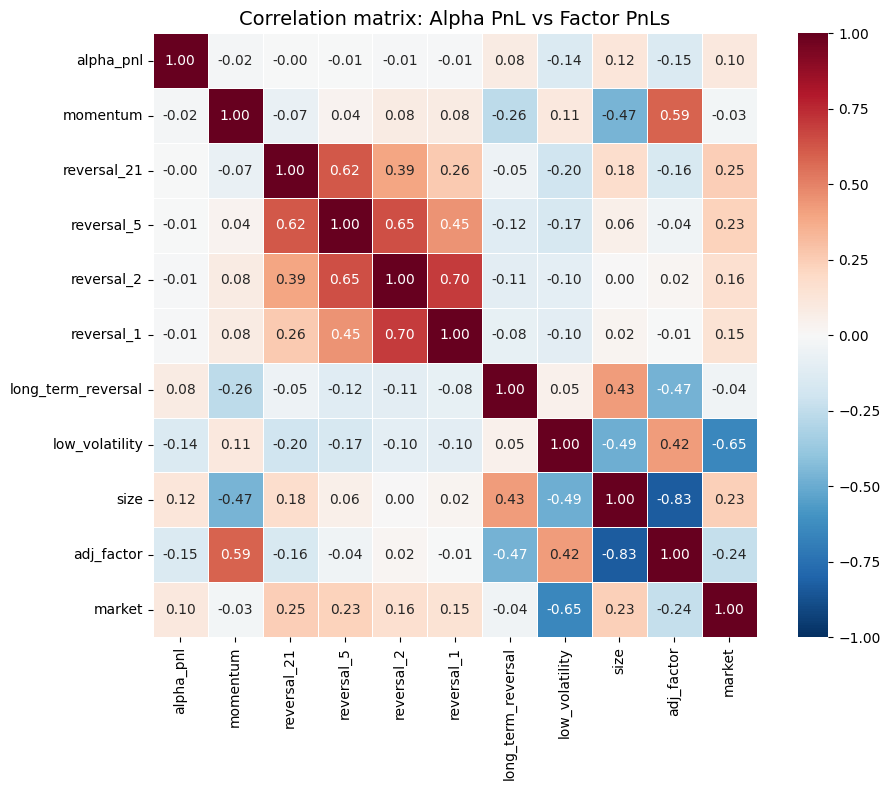

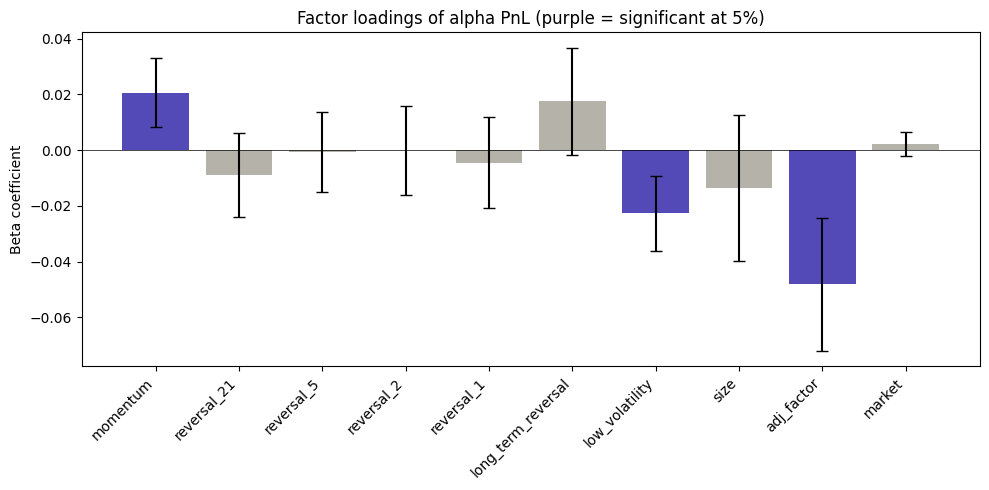

In [ ]:

reg_table = pd.DataFrame({
    "Coefficient": model.params,
    "Std Error": model.bse,
    "t-stat": model.tvalues,
    "p-value": model.pvalues,
}).round(4)

print("\n" + "="*60)
print("REGRESSION TABLE")
print("="*60)
print(reg_table.to_string())
print(f"\nR²: {model.rsquared:.4f}")
print(f"Jensen's alpha: {model.params['const']:.6f}")
print(f"  t-stat: {model.tvalues['const']:.3f}")
print(f"  p-value: {model.pvalues['const']:.4f}")
print(f"  Significant at 5%: {model.pvalues['const'] < 0.05}")



corr_matrix = combined.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title("Correlation matrix: Alpha PnL vs Factor PnLs", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
coefs = reg_table.drop(index="const")
colors = ["#534AB7" if p < 0.05 else "#B4B2A9" for p in coefs["p-value"]]
ax.bar(coefs.index, coefs["Coefficient"], yerr=1.96*coefs["Std Error"],
       color=colors, capsize=4, edgecolor="none")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Beta coefficient")
ax.set_title("Factor loadings of alpha PnL (purple = significant at 5%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("factor_loadings.png", dpi=150)
plt.show()